In [1]:
#Linear Regression packages
from sklearn.linear_model import LinearRegression

#Neural Network packages
from sklearn.neural_network import MLPRegressor

#Decision Tree packages
from sklearn.tree import DecisionTreeRegressor

#Random Forest Regressor packages
from sklearn.ensemble import RandomForestRegressor

#Gradient Boosting packages
from sklearn.ensemble import GradientBoostingRegressor

#ML packages
import sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GridSearchCV


#metrics
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from scipy import stats
from sklearn.model_selection import ShuffleSplit

#Graphics packages
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import scipy as sp

#Scientific computing and tables
import numpy as np
import pandas as pd

#Visualizations
import plotly
import plotly.graph_objects as go
import plotly.express as px
from sklearn.model_selection import LearningCurveDisplay, learning_curve
from sklearn.inspection import permutation_importance

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.options.display.float_format = '{:.2f}'.format

#Versions
from platform import python_version
print(f"Python version: {python_version()}")
print(f"scikit-learn version: {sklearn.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"pandas version: {pd.__version__}")
print(f"Matplotlib version: {mpl.__version__}")
print(f"Plotly version: {plotly.__version__}")
print(f"seaborn version: {sns.__version__}")
print(f"SciPy version: {sp.__version__}")

#Graph style
plt.style.use('default')

Python version: 3.12.4
scikit-learn version: 1.4.2
NumPy version: 1.26.4
pandas version: 2.2.2
Matplotlib version: 3.8.4
Plotly version: 5.22.0
seaborn version: 0.13.2
SciPy version: 1.13.1


In [2]:
# Loading the DataFrame file

df_original = pd.read_excel('principal_dataset.xlsx')

In [3]:
# Checking the first rows of the DataFrame

df_original.head()

,autor,sample_number,figure,medium_size_microparticle_(μm),microparticle_fraction_(wt%),coating_type,carrier_liquid_type,carrier_liquid_fraction_(wt%),carrier_liquid_viscosity_(cst),nanoparticle_type,medium_size_nanoparticle_(nm),nanoparticle_fraction_(wt%),SDS_fraction_(wt%),Stearic_acid_fraction_(wt%),fumed_silica_for_MRFs_fraction_(wt%),bentonite_fraction_(wt%),liquid_paraffin_fraction_(wt%),black_lead_fraction_(wt%),time_(h),sedimentation_rate_(%)
0,zhang2021,1,7a,4.00,40.00,none,silicone oil,54,100,none,0,0,2,0,0.00,1,2,1,1.49,7.58
1,zhang2021,1,7a,4.00,40.00,none,silicone oil,54,100,none,0,0,2,0,0.00,1,2,1,2.52,8.27
2,zhang2021,1,7a,4.00,40.00,none,silicone oil,54,100,none,0,0,2,0,0.00,1,2,1,3.45,3.15
3,zhang2021,1,7a,4.00,40.00,none,silicone oil,54,100,none,0,0,2,0,0.00,1,2,1,3.66,3.67
4,zhang2021,1,7a,4.00,40.00,none,silicone oil,54,100,none,0,0,2,0,0.00,1,2,1,3.89,4.24


In [4]:
# Deleting metadata

columns_delete = ['autor', 'sample_number', 'figure']
df_clean = df_original.drop(columns_delete, axis=1)

In [5]:
# Checking first rows of clean DataFrame

df_clean.head()

,medium_size_microparticle_(μm),microparticle_fraction_(wt%),coating_type,carrier_liquid_type,carrier_liquid_fraction_(wt%),carrier_liquid_viscosity_(cst),nanoparticle_type,medium_size_nanoparticle_(nm),nanoparticle_fraction_(wt%),SDS_fraction_(wt%),Stearic_acid_fraction_(wt%),fumed_silica_for_MRFs_fraction_(wt%),bentonite_fraction_(wt%),liquid_paraffin_fraction_(wt%),black_lead_fraction_(wt%),time_(h),sedimentation_rate_(%)
0,4.00,40.00,none,silicone oil,54,100,none,0,0,2,0,0.00,1,2,1,1.49,7.58
1,4.00,40.00,none,silicone oil,54,100,none,0,0,2,0,0.00,1,2,1,2.52,8.27
2,4.00,40.00,none,silicone oil,54,100,none,0,0,2,0,0.00,1,2,1,3.45,3.15
3,4.00,40.00,none,silicone oil,54,100,none,0,0,2,0,0.00,1,2,1,3.66,3.67
4,4.00,40.00,none,silicone oil,54,100,none,0,0,2,0,0.00,1,2,1,3.89,4.24


In [6]:
# Checking file information

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 17 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   medium_size_microparticle_(μm)        4898 non-null   float64
 1   microparticle_fraction_(wt%)          4898 non-null   float64
 2   coating_type                          4898 non-null   object 
 3   carrier_liquid_type                   4898 non-null   object 
 4   carrier_liquid_fraction_(wt%)         4898 non-null   int64  
 5   carrier_liquid_viscosity_(cst)        4898 non-null   int64  
 6   nanoparticle_type                     4898 non-null   object 
 7   medium_size_nanoparticle_(nm)         4898 non-null   int64  
 8   nanoparticle_fraction_(wt%)           4898 non-null   int64  
 9   SDS_fraction_(wt%)                    4898 non-null   int64  
 10  Stearic_acid_fraction_(wt%)           4898 non-null   int64  
 11  fumed_silica_for_

In [7]:
# Total unique values ​​for each variable

unique_values = []
for i in df_clean.columns[0:17].tolist():
    print(i, ':', len(df_clean[i].astype(str).value_counts()))
    unique_values.append(len(df_clean[i].astype(str).value_counts()))

medium_size_microparticle_(μm) : 6
microparticle_fraction_(wt%) : 36
coating_type : 4
carrier_liquid_type : 2
carrier_liquid_fraction_(wt%) : 25
carrier_liquid_viscosity_(cst) : 4
nanoparticle_type : 3
medium_size_nanoparticle_(nm) : 2
nanoparticle_fraction_(wt%) : 3
SDS_fraction_(wt%) : 5
Stearic_acid_fraction_(wt%) : 5
fumed_silica_for_MRFs_fraction_(wt%) : 23
bentonite_fraction_(wt%) : 2
liquid_paraffin_fraction_(wt%) : 2
black_lead_fraction_(wt%) : 2
time_(h) : 3806
sedimentation_rate_(%) : 2954


In [8]:
# Checking file dimensions

df_clean.shape

(4898, 17)

In [9]:
# Selecting numeric columns only
df_numeric = df_clean.select_dtypes(include=['number'])

# Counting how many rows have at least one negative value
count_negative_lines = df_numeric.lt(0).any(axis=1).sum()

print(f"Total rows with negative values: {count_negative_lines}")

Total rows with negative values: 0


In [10]:
# Viewing some statistical measures

df_clean.describe()

,medium_size_microparticle_(μm),microparticle_fraction_(wt%),carrier_liquid_fraction_(wt%),carrier_liquid_viscosity_(cst),medium_size_nanoparticle_(nm),nanoparticle_fraction_(wt%),SDS_fraction_(wt%),Stearic_acid_fraction_(wt%),fumed_silica_for_MRFs_fraction_(wt%),bentonite_fraction_(wt%),liquid_paraffin_fraction_(wt%),black_lead_fraction_(wt%),time_(h),sedimentation_rate_(%)
count,4898.00,4898.00,4898.00,4898.00,4898.00,4898.00,4898.00,4898.00,4898.00,4898.00,4898.00,4898.00,4898.00,4898.00
mean,4.41,51.67,43.68,205.18,0.22,0.16,1.01,0.94,0.28,0.57,1.13,0.57,725.59,27.87
std,0.74,10.36,10.30,280.99,1.62,1.36,1.69,1.65,0.50,0.50,0.99,0.50,664.35,18.68
min,2.00,27.90,25.00,50.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.08,0.00
25%,4.00,40.00,35.00,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,120.34,13.10
50%,4.00,50.00,41.00,100.00,0.00,0.00,0.00,0.00,0.00,1.00,2.00,1.00,527.17,25.80
75%,5.50,60.00,51.00,100.00,0.00,0.00,2.00,2.00,0.40,1.00,2.00,1.00,1205.98,37.99
max,5.50,70.00,70.00,1023.00,12.00,13.00,5.00,5.00,2.10,1.00,2.00,1.00,2410.97,87.77


In [11]:
# Analyze possible outliers
numeric_variables = []
for i in df_clean.columns[0:17].tolist():
        if df_clean.dtypes[i] == 'int64' or df_clean.dtypes[i] == 'float64':                        
            numeric_variables.append(i)   

In [12]:
numeric_variables

['medium_size_microparticle_(μm)',
 'microparticle_fraction_(wt%)',
 'carrier_liquid_fraction_(wt%)',
 'carrier_liquid_viscosity_(cst)',
 'medium_size_nanoparticle_(nm)',
 'nanoparticle_fraction_(wt%)',
 'SDS_fraction_(wt%)',
 'Stearic_acid_fraction_(wt%)',
 'fumed_silica_for_MRFs_fraction_(wt%)',
 'bentonite_fraction_(wt%)',
 'liquid_paraffin_fraction_(wt%)',
 'black_lead_fraction_(wt%)',
 'time_(h)',
 'sedimentation_rate_(%)']

In [13]:
len(numeric_variables)

14

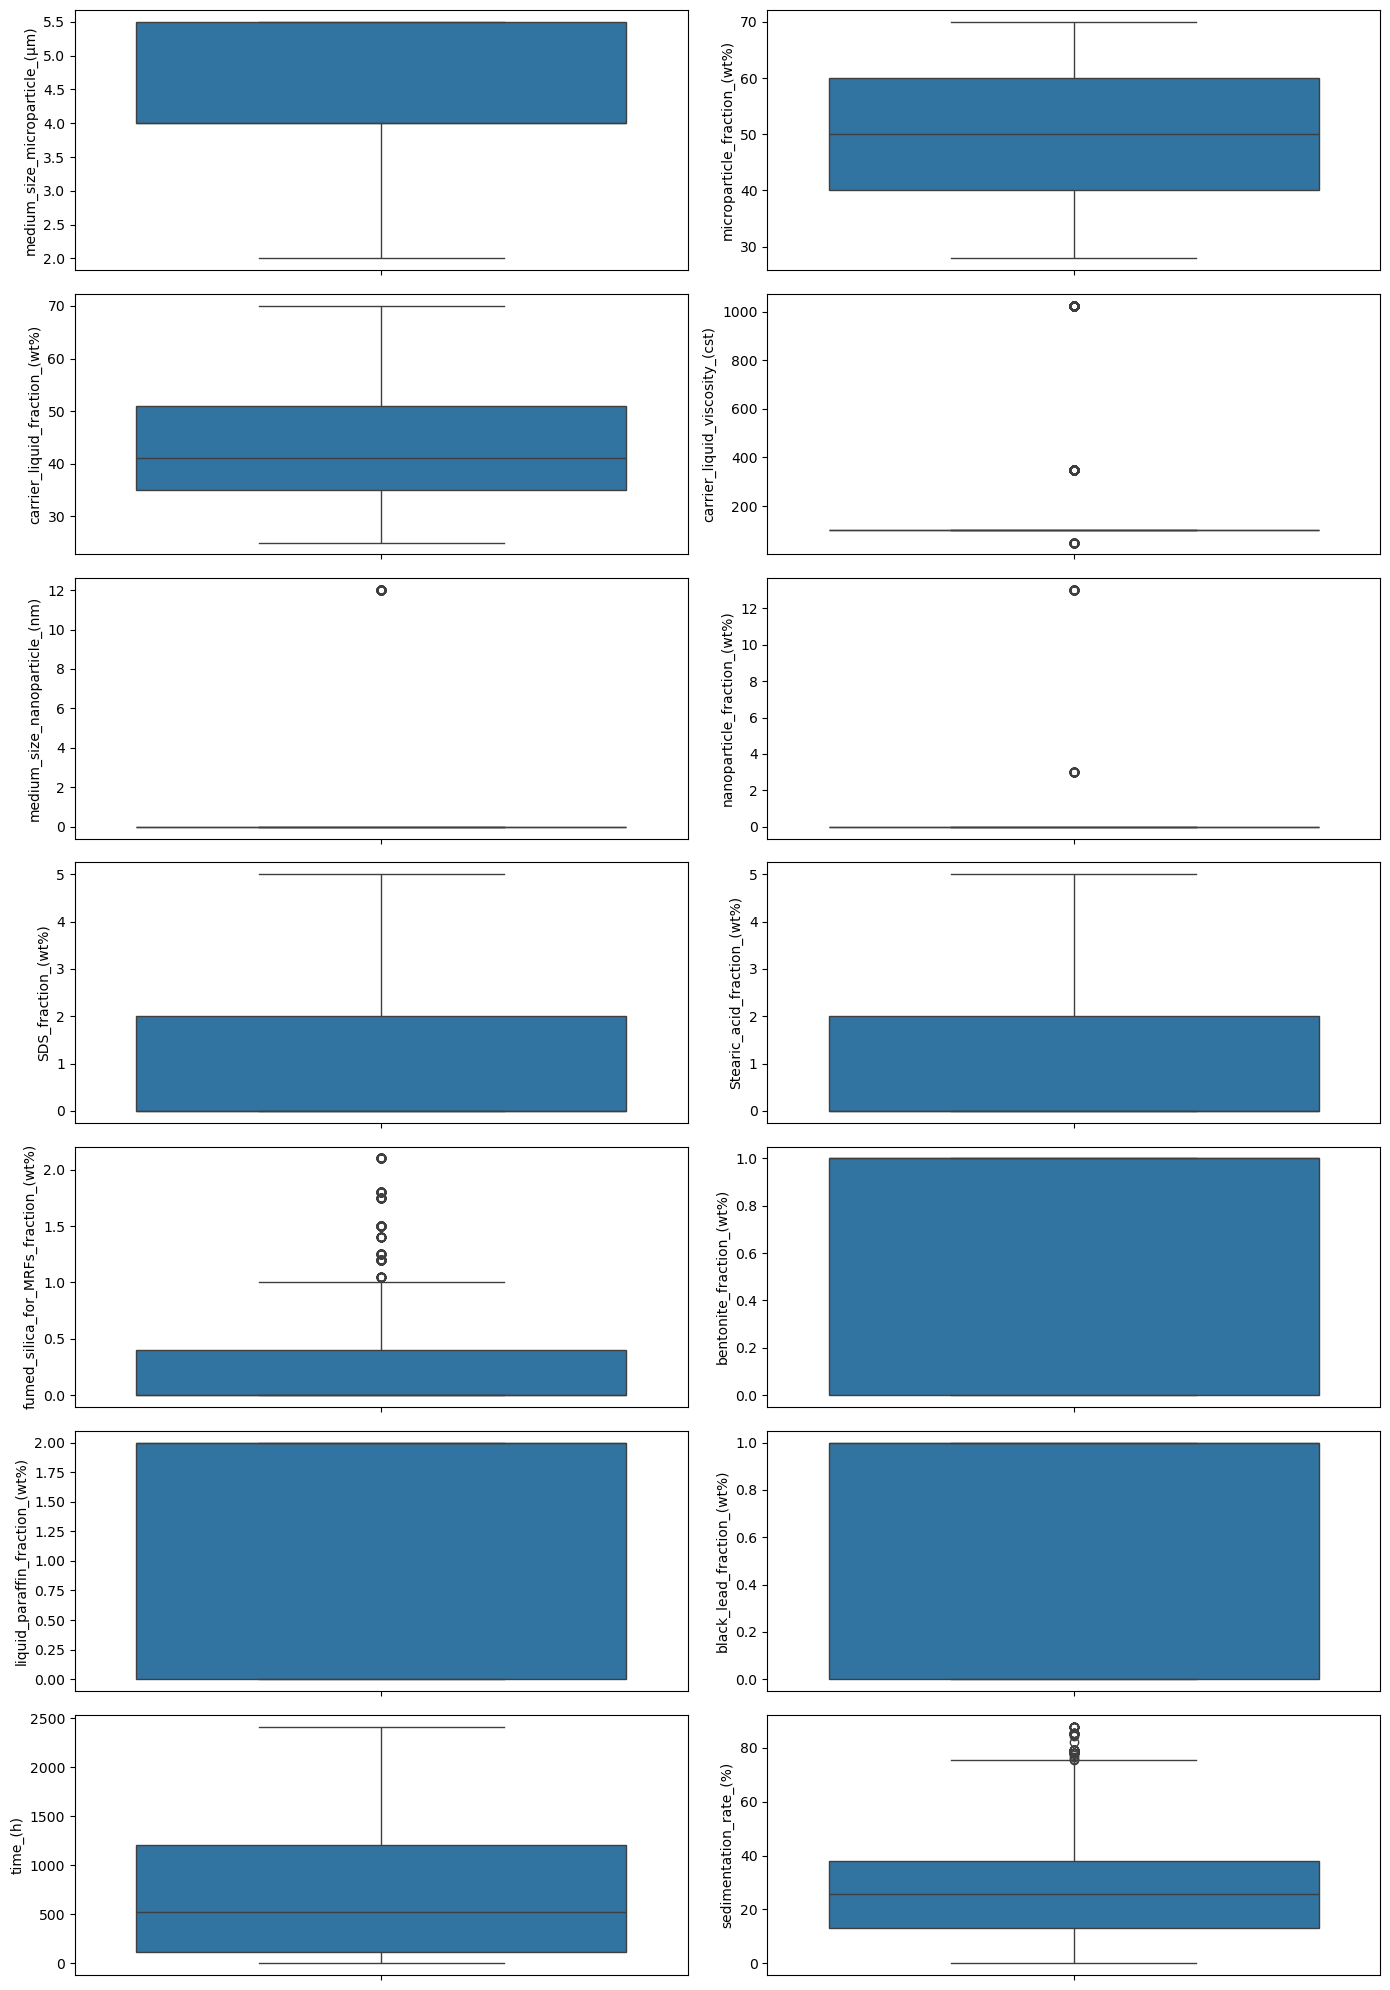

In [14]:
# Visualizing possible outliers through graphs

plt.rcParams["figure.figsize"] = [14.00, 20.00]
plt.rcParams["figure.autolayout"] = True
f, axes = plt.subplots(7, 2)

row = 0
column = 0
for i in numeric_variables:
    sns.boxplot(data = df_clean, y=i, ax=axes[row][column])
    column += 1
    if column == 2:
        row += 1
        column = 0
        
plt.show()

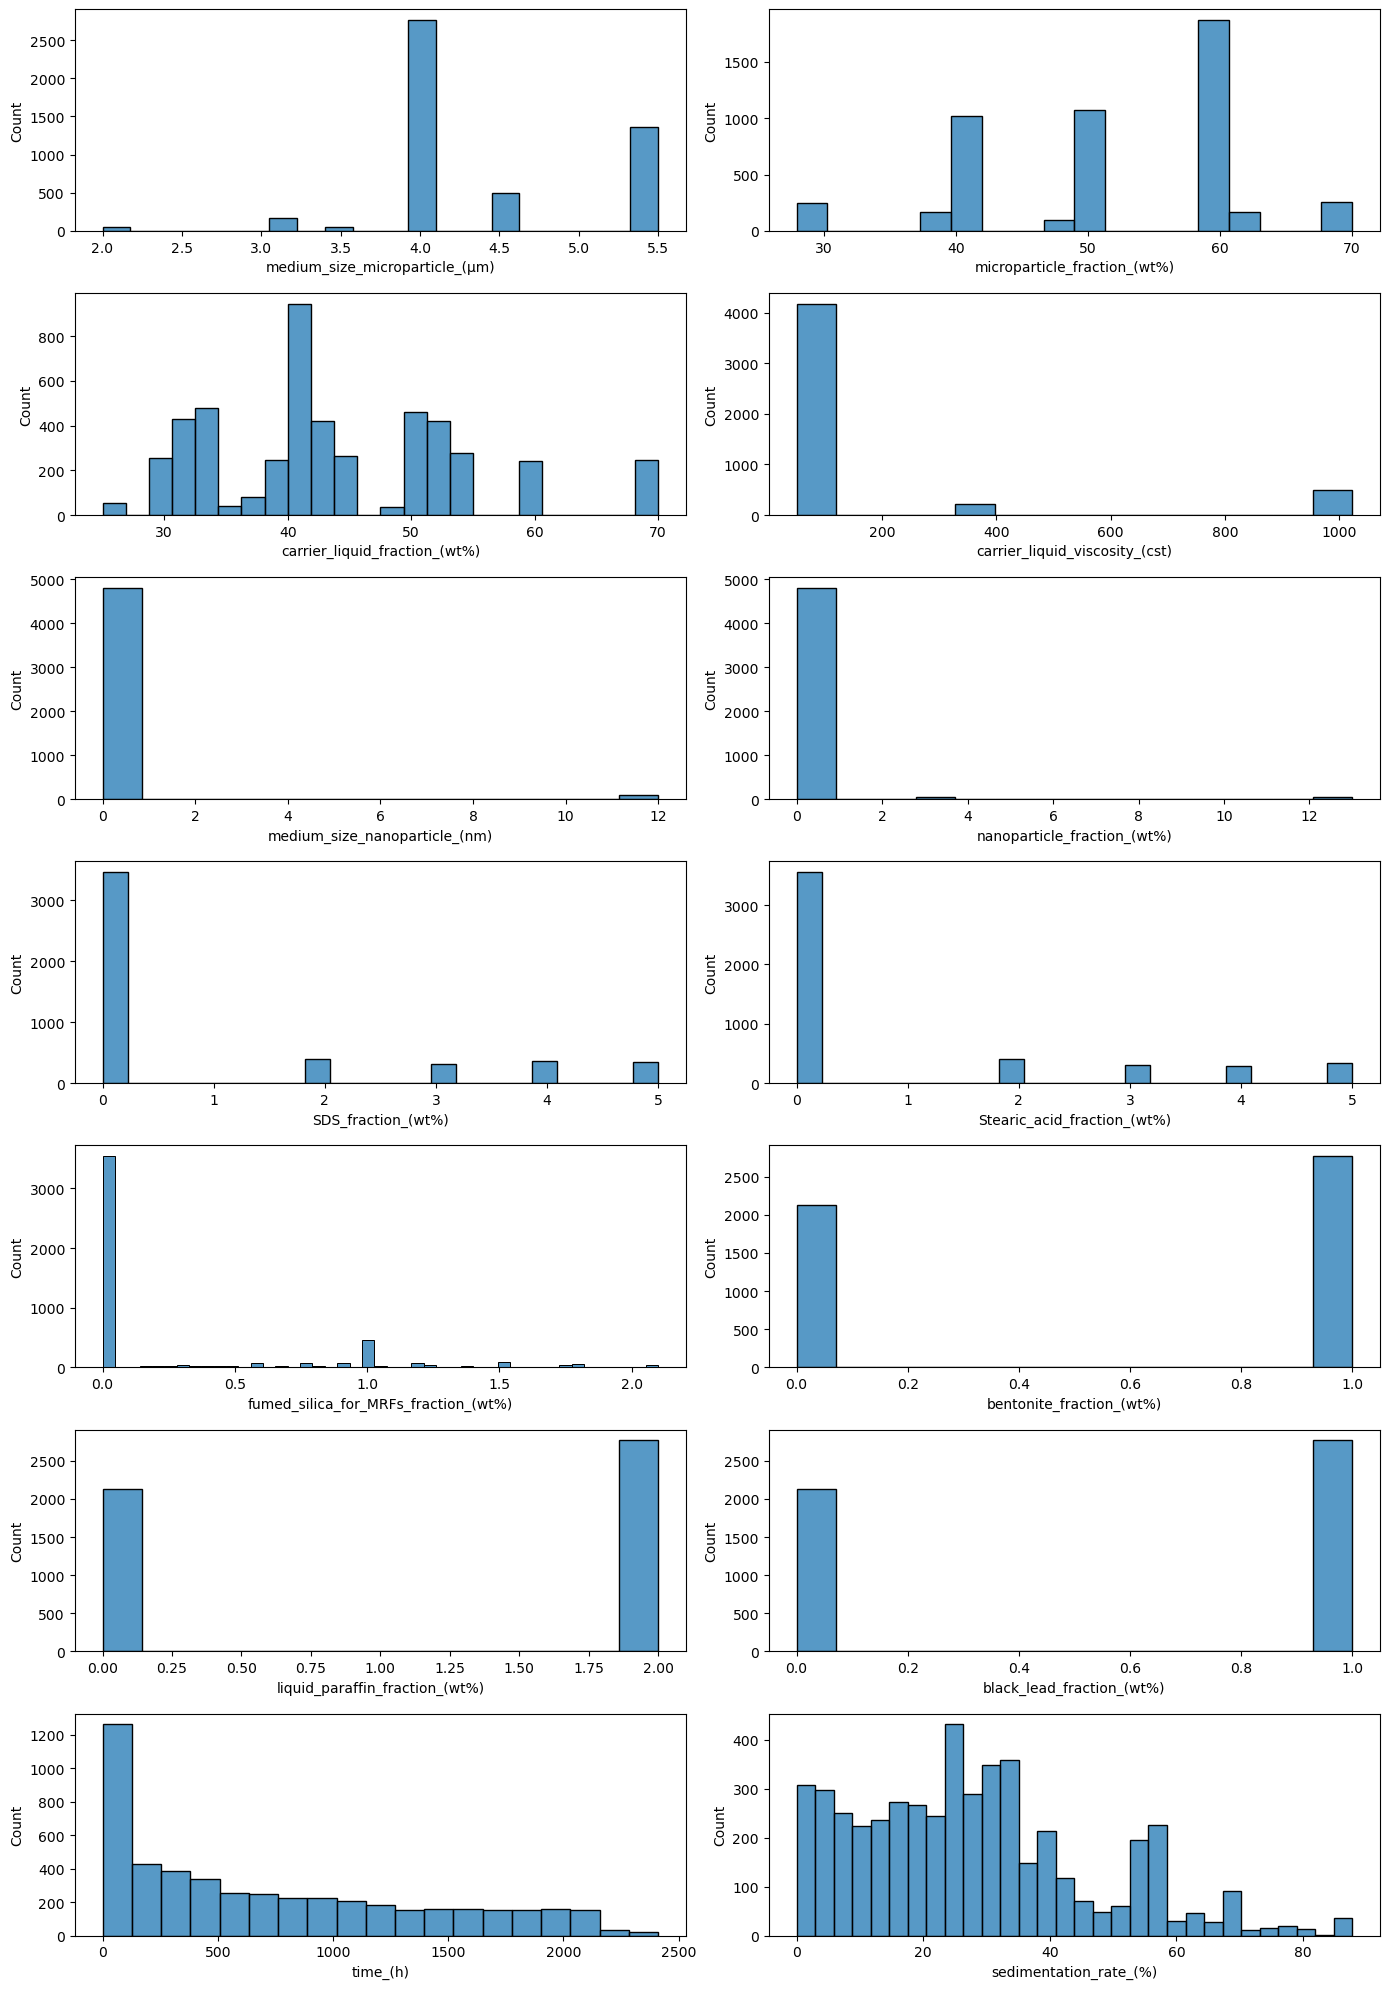

In [15]:
# Analyze data distribution

plt.rcParams["figure.figsize"] = [14.00, 20.00]
plt.rcParams["figure.autolayout"] = True
f, axes = plt.subplots(7, 2)

row = 0
column = 0
for i in numeric_variables:
    sns.histplot(data = df_clean, x=i, ax=axes[row][column])
    column += 1
    if column == 2:
        row += 1
        column = 0            

plt.show()

In [16]:
#Creating a dictionary to store test results
normality_results = {}

In [17]:
for column in numeric_variables:
    #Getting column data
    data = df_clean[column]
    
#Calculating the mean and standard deviation of data
    mean = np.nanmean(data)
    std_dev = np.nanstd(data)
    
#Applying the Kolmogorov-Smirnov Test for normality
#Comparing the empirical distribution of data with the normal distribution
    stat, p_value = stats.kstest(data, 'norm', args=(mean, std_dev))

#Storing the results in the dictionary
    normality_results[column] = {'statistic': stat, 'p_value': p_value}

In [18]:
#Print results
for column, result in normality_results.items():
    print(f'Variable: {column}')
    print(f'  Statistic: {result["statistic"]:.5f}')
    print(f'  p_value: {result["p_value"]:.5f}')
    if result["p_value"] > 0.05:
        print('  The variable appears to be normal (p > 0.05)')
    else:
        print('  The variable does not appear to be normal (p <= 0.05)')
    print('---')

Variable: medium_size_microparticle_(μm)
  Statistic: 0.33320
  p_value: 0.00000
  The variable does not appear to be normal (p <= 0.05)
---
Variable: microparticle_fraction_(wt%)
  Statistic: 0.22420
  p_value: 0.00000
  The variable does not appear to be normal (p <= 0.05)
---
Variable: carrier_liquid_fraction_(wt%)
  Statistic: 0.14412
  p_value: 0.00000
  The variable does not appear to be normal (p <= 0.05)
---
Variable: carrier_liquid_viscosity_(cst)
  Statistic: 0.49832
  p_value: 0.00000
  The variable does not appear to be normal (p <= 0.05)
---
Variable: medium_size_nanoparticle_(nm)
  Statistic: 0.53614
  p_value: 0.00000
  The variable does not appear to be normal (p <= 0.05)
---
Variable: nanoparticle_fraction_(wt%)
  Statistic: 0.52893
  p_value: 0.00000
  The variable does not appear to be normal (p <= 0.05)
---
Variable: SDS_fraction_(wt%)
  Statistic: 0.43324
  p_value: 0.00000
  The variable does not appear to be normal (p <= 0.05)
---
Variable: Stearic_acid_fraction_

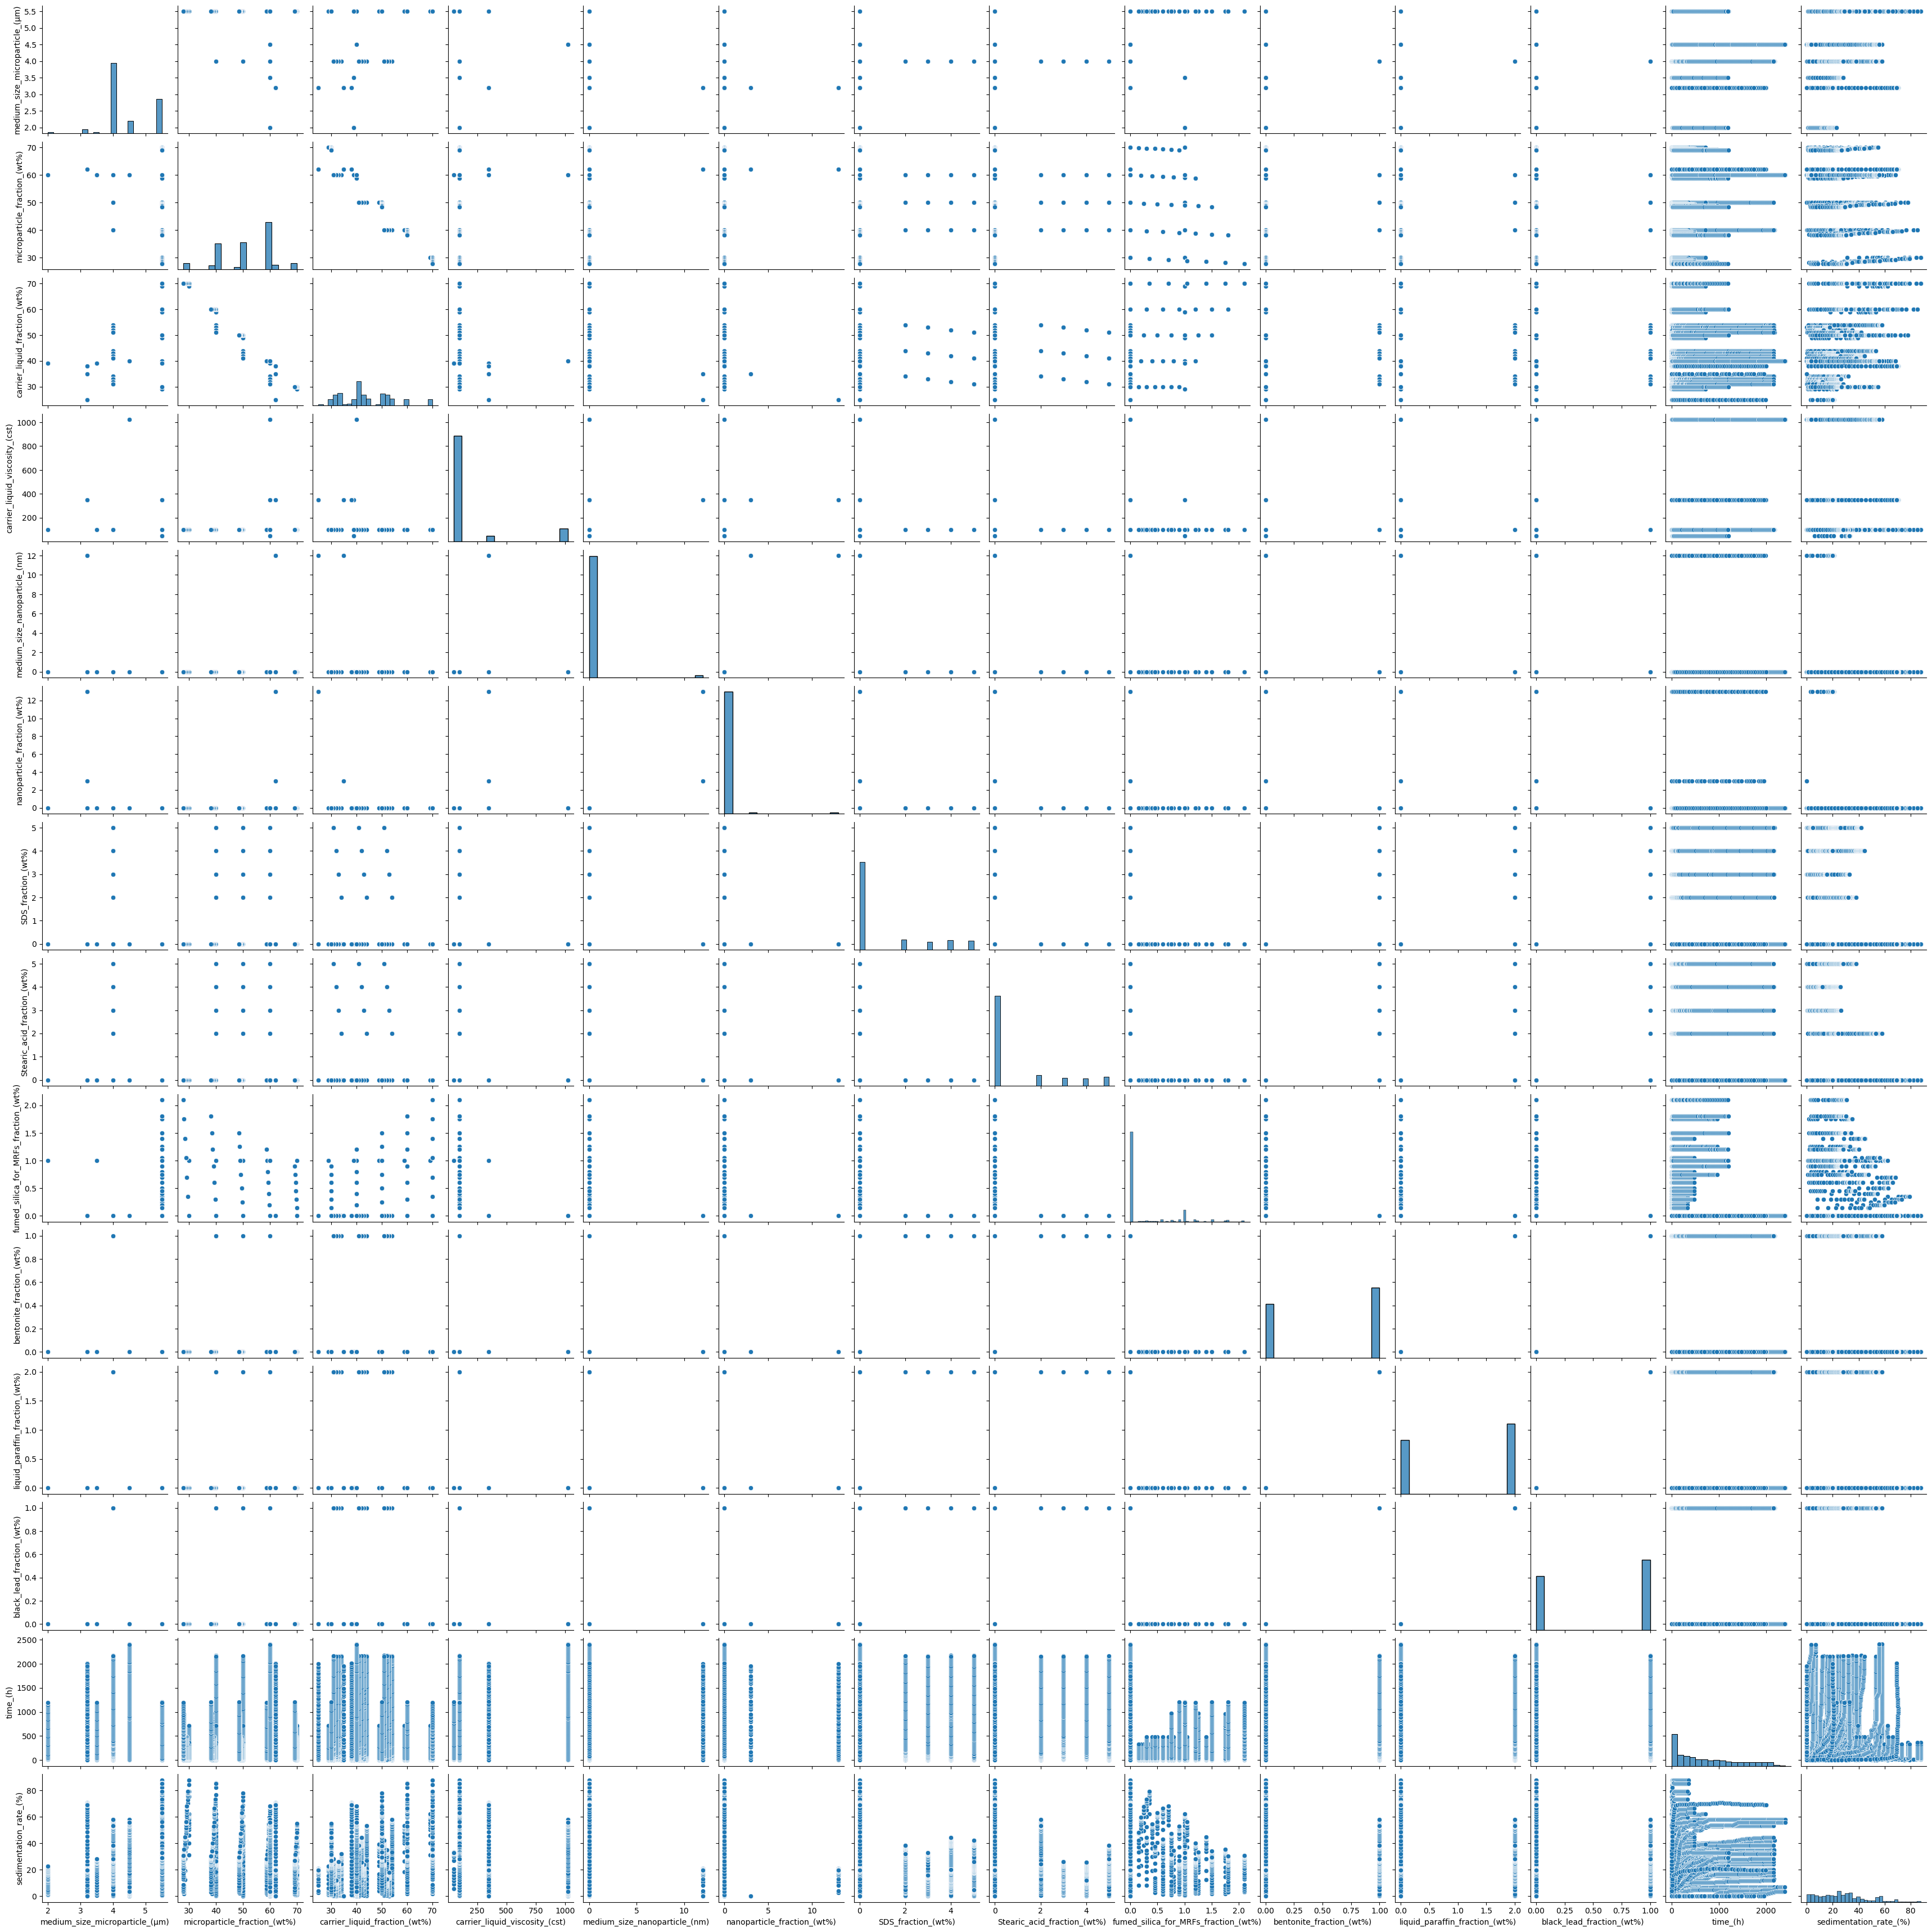

In [19]:
sns.pairplot(df_clean[['medium_size_microparticle_(μm)', 'microparticle_fraction_(wt%)', 'carrier_liquid_fraction_(wt%)', 'carrier_liquid_viscosity_(cst)', 'medium_size_nanoparticle_(nm)', 'nanoparticle_fraction_(wt%)',  'SDS_fraction_(wt%)', 'Stearic_acid_fraction_(wt%)', 'fumed_silica_for_MRFs_fraction_(wt%)', 'bentonite_fraction_(wt%)', 'liquid_paraffin_fraction_(wt%)', 'black_lead_fraction_(wt%)', 'time_(h)', 'sedimentation_rate_(%)']])

In [20]:
# Treating string data, create the encoder.

lb = LabelEncoder()

for var in ['coating_type','carrier_liquid_type','nanoparticle_type']:
    df_clean[var] = lb.fit_transform(df_clean[var])

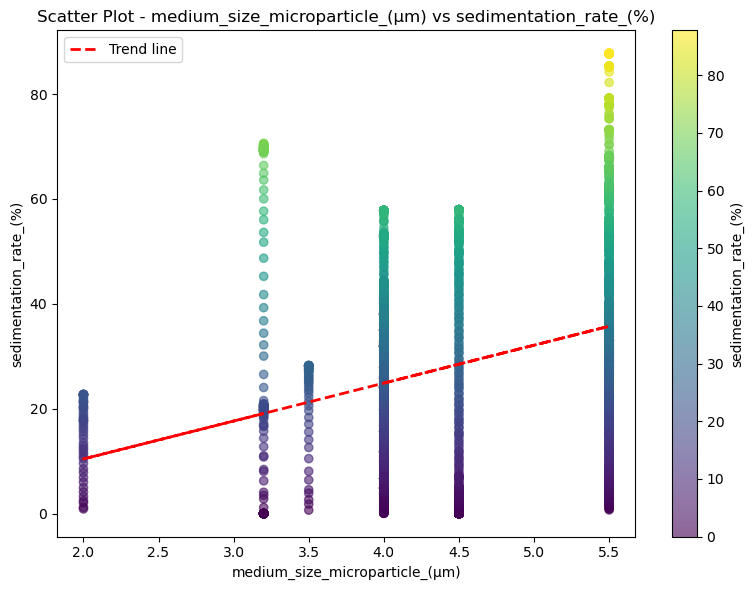

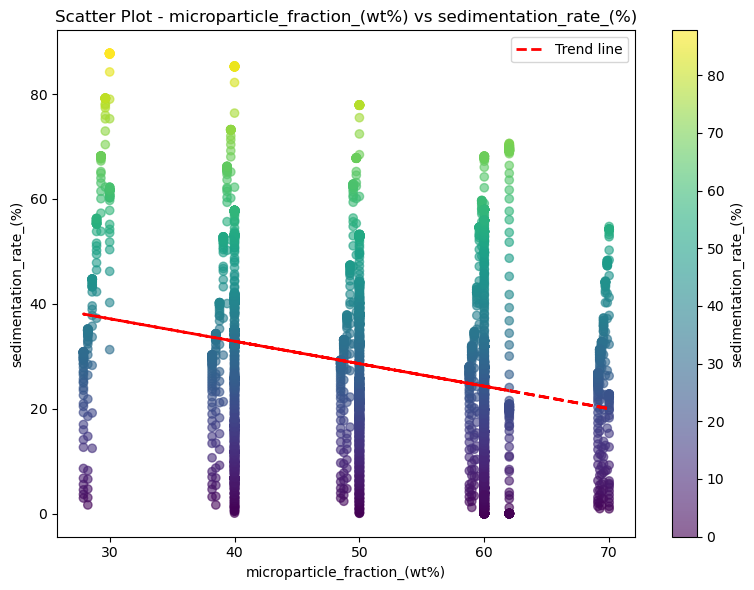

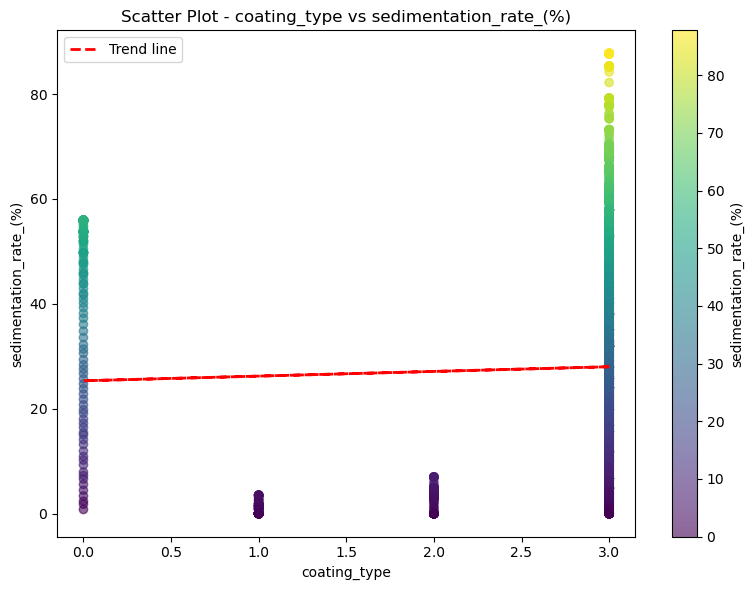

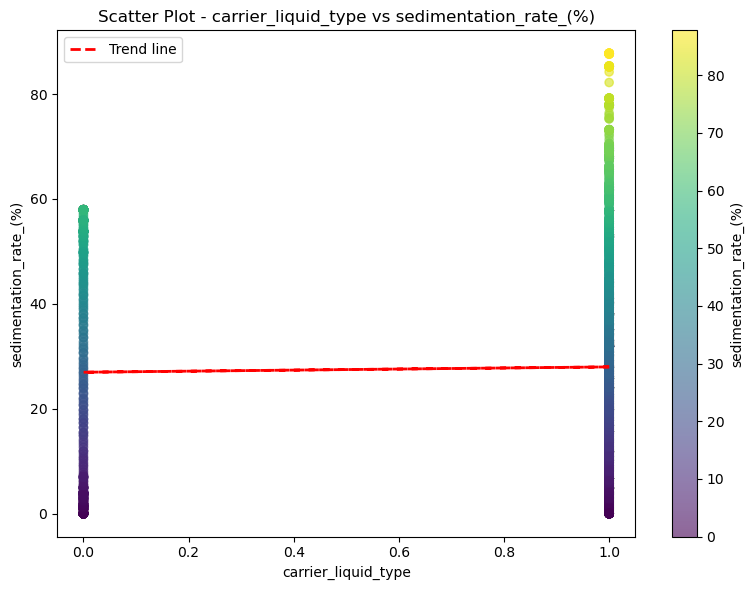

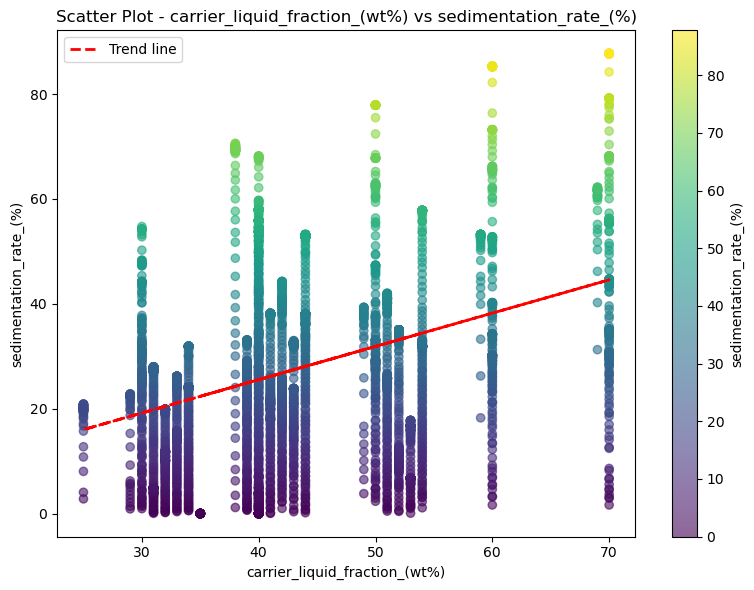

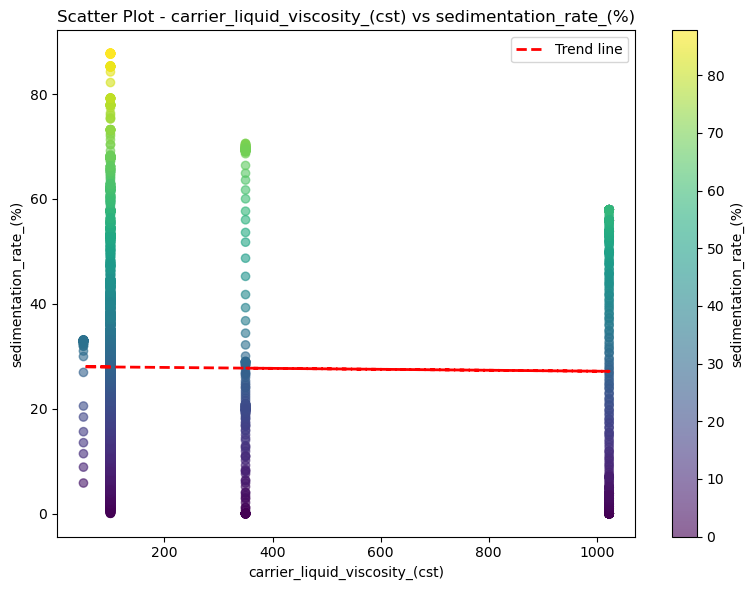

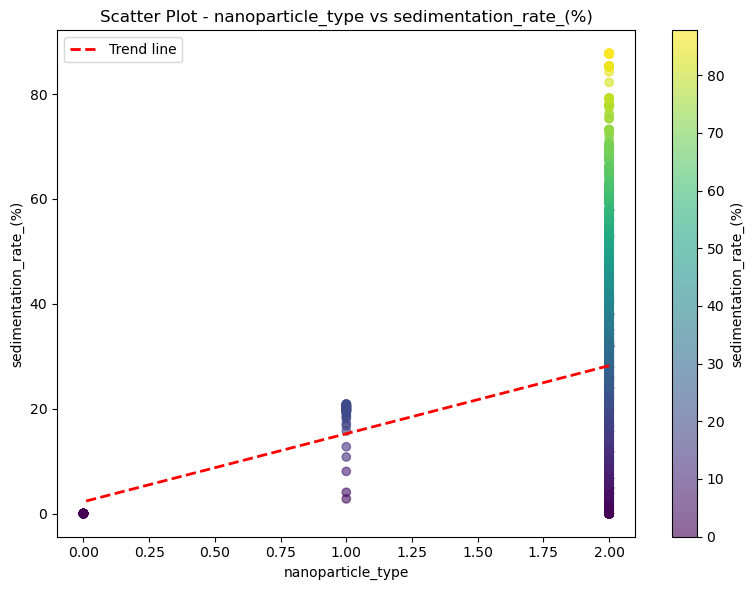

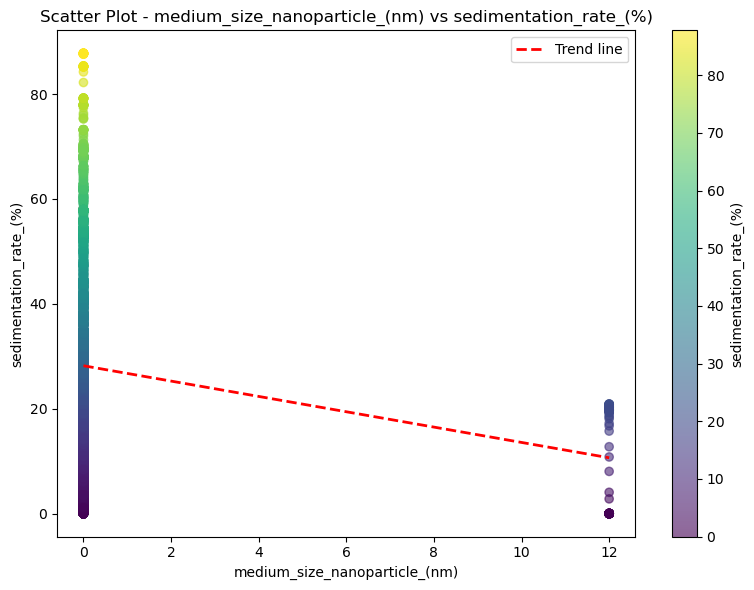

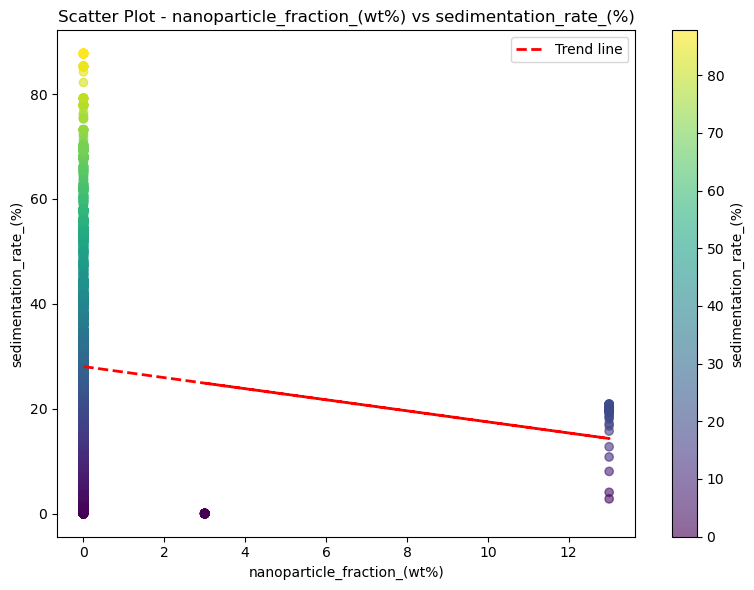

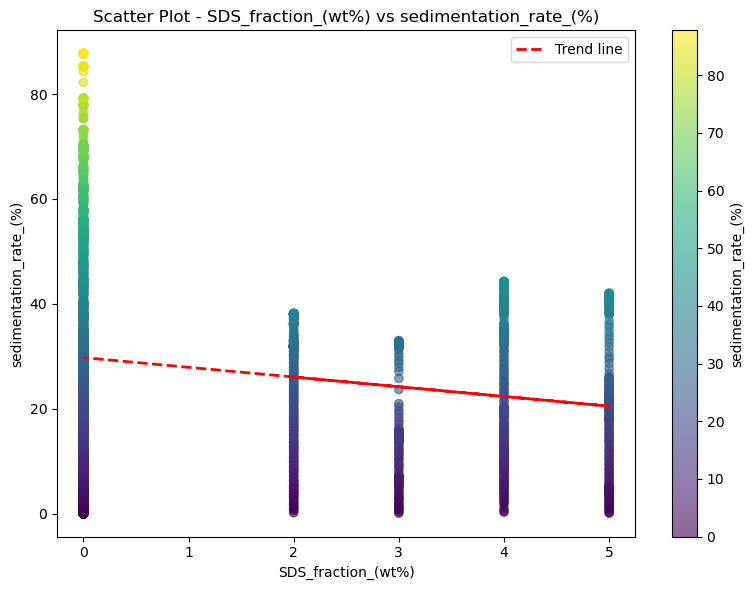

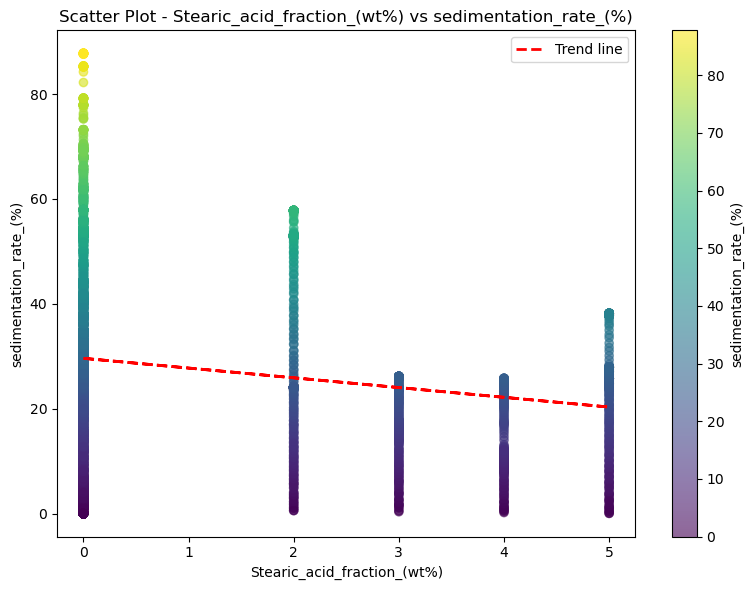

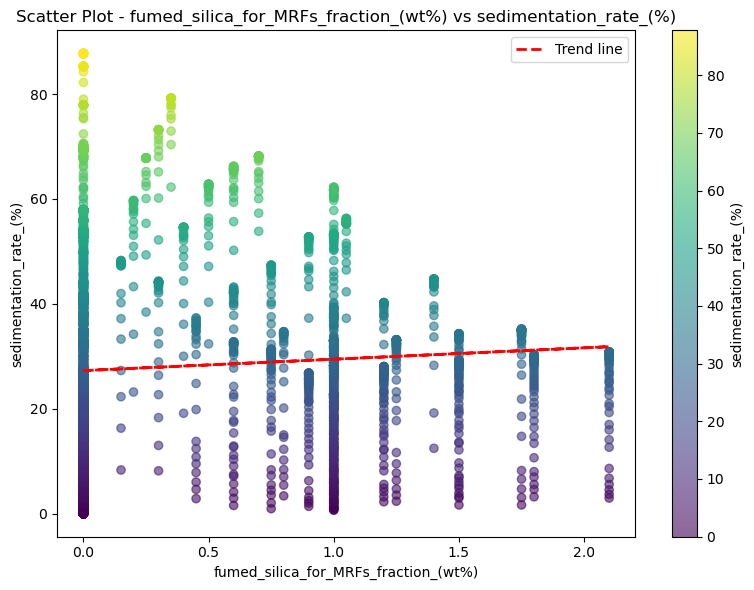

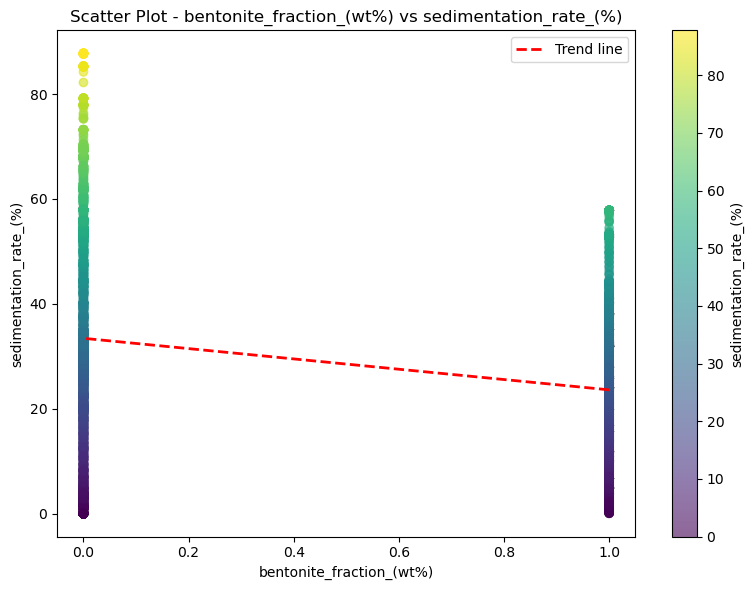

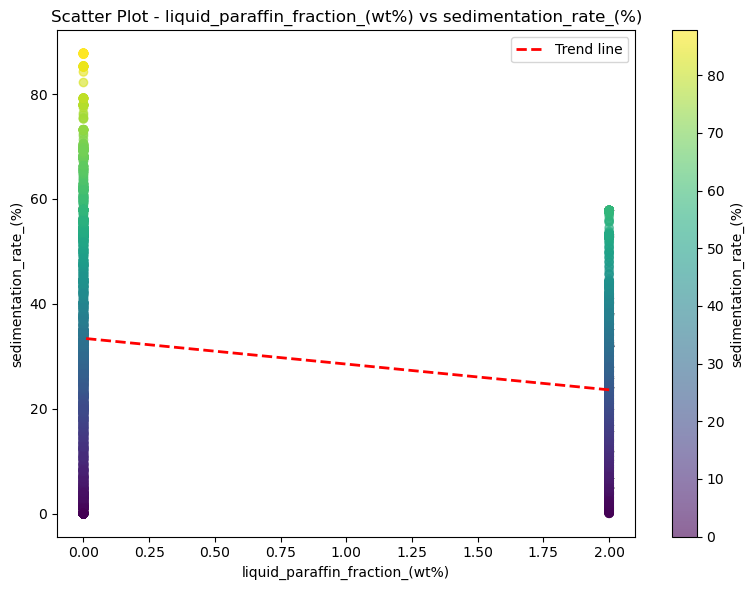

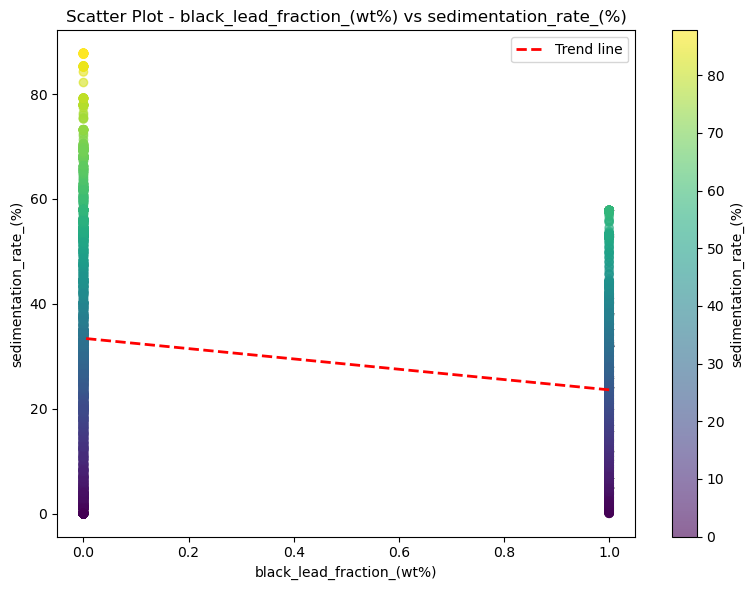

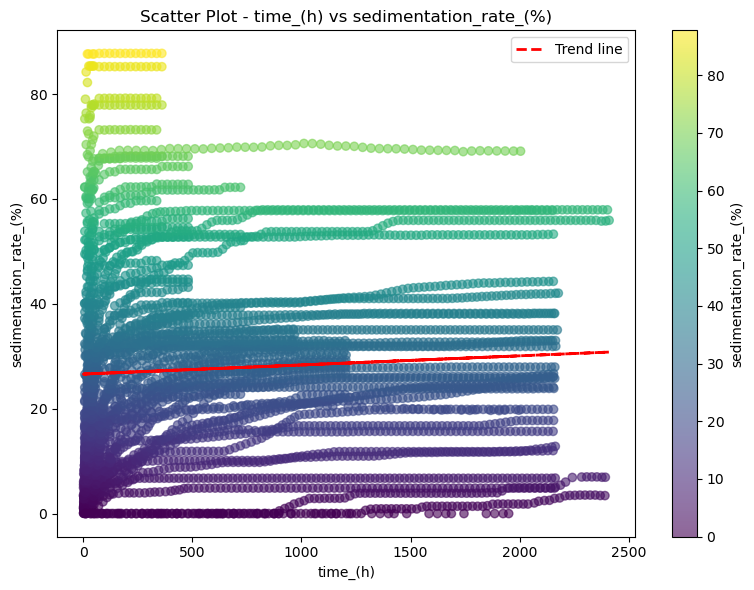

In [21]:
target_col = 'sedimentation_rate_(%)'

for col in df_clean.columns:
    if col == target_col:
        continue  
    
    plt.figure(figsize=(8, 6))
    plt.scatter(df_clean[col], df_clean[target_col], alpha=0.6, c=df_clean[target_col], cmap='viridis')
    plt.title(f'Scatter Plot - {col} vs {target_col}')
    plt.xlabel(col)
    plt.ylabel(target_col)

    # Trend. line
    z = np.polyfit(df_clean[col], df_clean[target_col], 1)
    p = np.poly1d(z)
    plt.plot(df_clean[col], p(df_clean[col]), "r--", linewidth=2, label='Trend line')
    plt.legend()

    plt.colorbar(label=target_col)
    plt.tight_layout()
    plt.show()


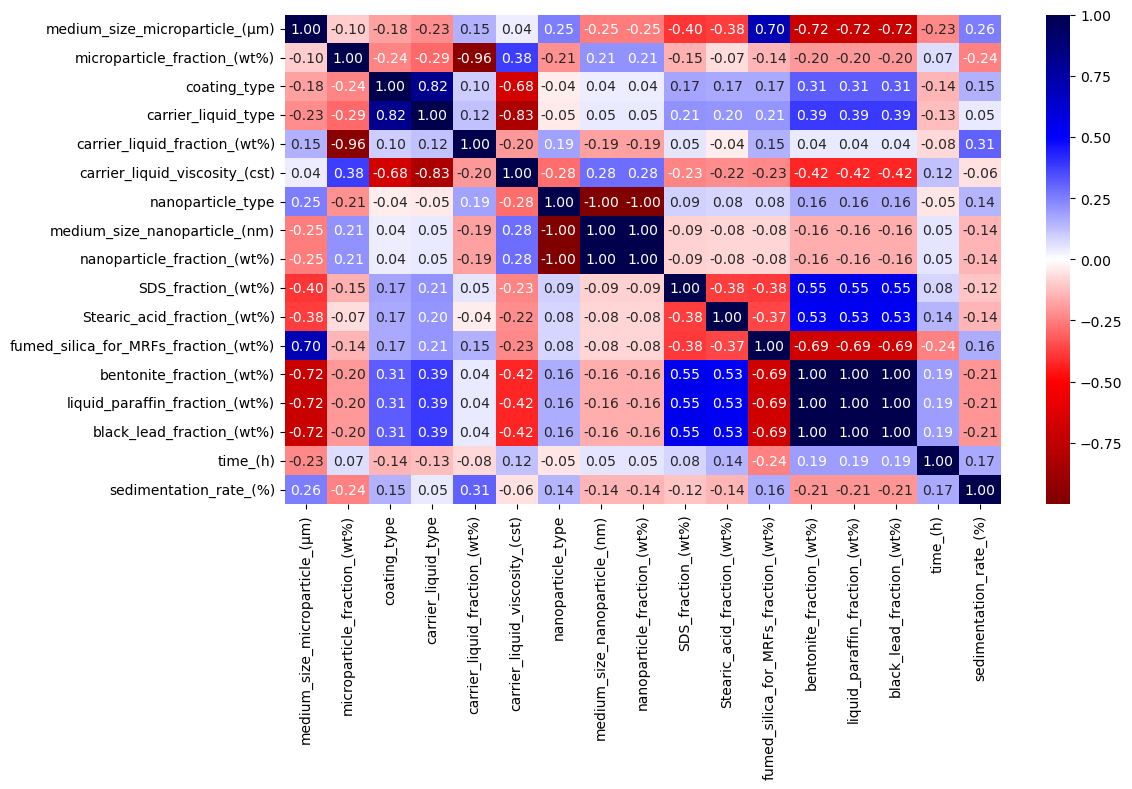

In [22]:
#Correlation between variables (Spearman)
corr_spearman = df_clean.corr(method='spearman')

plt.figure(figsize=(12, 8))
sns.heatmap(corr_spearman, annot=True, cmap='seismic_r', fmt='.2f')
plt.show()

In [23]:
df_clean['sedimentation_rate_(%)'] = df_clean['sedimentation_rate_(%)']/100

In [24]:
#Separating predictor and target variables

X = df_clean[ df_clean.columns[:-1]]
y = df_clean[ df_clean.columns[-1:]]

In [25]:
#Scale the data
stdScaler = StandardScaler()
 
# z = (x - u) /s
X1 = stdScaler.fit_transform(X) 

In [26]:
#Splitting into training and testing data

X_train, X_test, y_train, y_test = train_test_split(X1, y, test_size=0.2, random_state = 42)

In [27]:
#Converting 'y' to one-dimensional (1D) vector to avoid warnings
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

In [28]:
#Linear Regression (LR) model
regressor_LR = LinearRegression()

In [29]:
#Training the model
regressor_LR = regressor_LR.fit(X_train, y_train)

In [30]:
#Calculating predictions for the training and testing set
y_train_pred_LR = regressor_LR.predict(X_train)
y_test_pred_LR = regressor_LR.predict(X_test)

In [31]:
# The coefficients
print("Coefficients: \n", regressor_LR.coef_)

Coefficients: 
 [ 2.43174715e-02 -2.40808468e+12  7.96417011e-03  8.35017396e-02
 -2.39558630e+12 -1.89222426e-02  1.20750613e+12  1.83512738e+12
 -1.11685232e+12 -3.93743089e+11 -3.82671619e+11 -1.17325142e+11
 -1.53697370e+11 -1.53697370e+11 -1.53697370e+11  5.09890892e-02]


In [32]:
print("Intercept: ", regressor_LR.intercept_)

Intercept:  0.2816914420191252


In [33]:
#Calculating performance evaluation metrics
print(f"R2 Train: {r2_score(y_train, y_train_pred_LR):.5f}")
print(f"R2 Test: {r2_score(y_test, y_test_pred_LR):.5f}")
print(f"RMSE Train: {root_mean_squared_error(y_train, y_train_pred_LR):.5f}")
print(f"RMSE Test: {root_mean_squared_error(y_test, y_test_pred_LR):.5f}")
print(f"MAE Train: {mean_absolute_error(y_train, y_train_pred_LR):.5f}")
print(f"MAE Test: {mean_absolute_error(y_test, y_test_pred_LR):.5f}")


R2 Train: 0.49273
R2 Test: 0.43847
RMSE Train: 0.13252
RMSE Test: 0.14199
MAE Train: 0.10093
MAE Test: 0.11008


In [34]:
#Function to show R2 on the graph
def annotate(data, **kws):
    r, p = sp.stats.pearsonr(data['sedimentation_rate_(%)'], data['Predicted'])
    r = float(r) ** 2
    err = root_mean_squared_error(data['sedimentation_rate_(%)'], data['Predicted'])
    ax = plt.gca()

    ax.text(.05, .8, 'r2={:.5f}, p={:.5f}, RMSE={:.5f}'.format(r, p, err),
            transform=ax.transAxes)

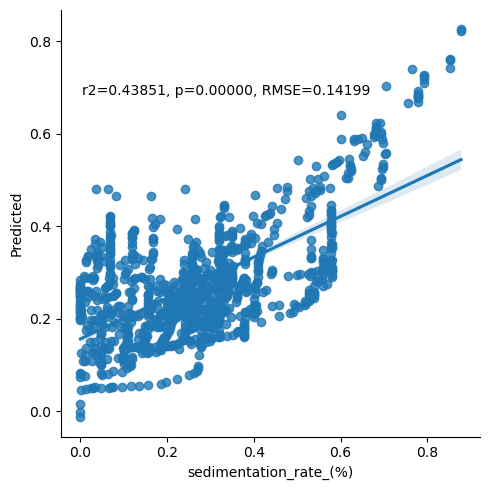

In [35]:
#Visualization Multiple Linear Regression
df = pd.DataFrame()
df['sedimentation_rate_(%)'] = y_test
df['Predicted'] = y_test_pred_LR

g = sns.lmplot(x = 'sedimentation_rate_(%)', y = 'Predicted', data = df, ci = 90)
g.map_dataframe(annotate)
plt.show()

In [36]:
#Grid Search Multi-Layer Perceptron (MLP)
param_grid = {
    'hidden_layer_sizes': [(100,), (50, 50), (100, 50)],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.0005],
}

regressor_MLP = MLPRegressor(
    random_state=42,
    max_iter=10000,
    n_iter_no_change=100,
    tol=1e-4,
    solver='adam',
    verbose=True,
    early_stopping=True,
    validation_fraction=0.1
)

grid_search_MLP = GridSearchCV(
    regressor_MLP,
    param_grid,
    cv=5,                 
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search_MLP.fit(X_train, y_train)

print("Best parameters found:", grid_search_MLP.best_params_)
print("Best R² (cross validation):", grid_search_MLP.best_score_)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Iteration 1, loss = 0.05330119
Validation score: -0.179381
Iteration 2, loss = 0.01738058
Validation score: 0.380981
Iteration 3, loss = 0.01002810
Validation score: 0.567300
Iteration 4, loss = 0.00747397
Validation score: 0.648334
Iteration 5, loss = 0.00614202
Validation score: 0.690873
Iteration 6, loss = 0.00533799
Validation score: 0.727075
Iteration 7, loss = 0.00476355
Validation score: 0.742846
Iteration 8, loss = 0.00444153
Validation score: 0.764094
Iteration 9, loss = 0.00405694
Validation score: 0.788749
Iteration 10, loss = 0.00380028
Validation score: 0.796096
Iteration 11, loss = 0.00362135
Validation score: 0.809809
Iteration 12, loss = 0.00338874
Validation score: 0.817086
Iteration 13, loss = 0.00321669
Validation score: 0.826934
Iteration 14, loss = 0.00308538
Validation score: 0.832541
Iteration 15, loss = 0.00294910
Validation score: 0.835607
Iteration 16, loss = 0.00286095
Validation score: 0.846732
Ite

In [37]:
#Multi-Layer Perceptron (MLP) model
best_model_MLP = grid_search_MLP.best_estimator_

<Axes: >

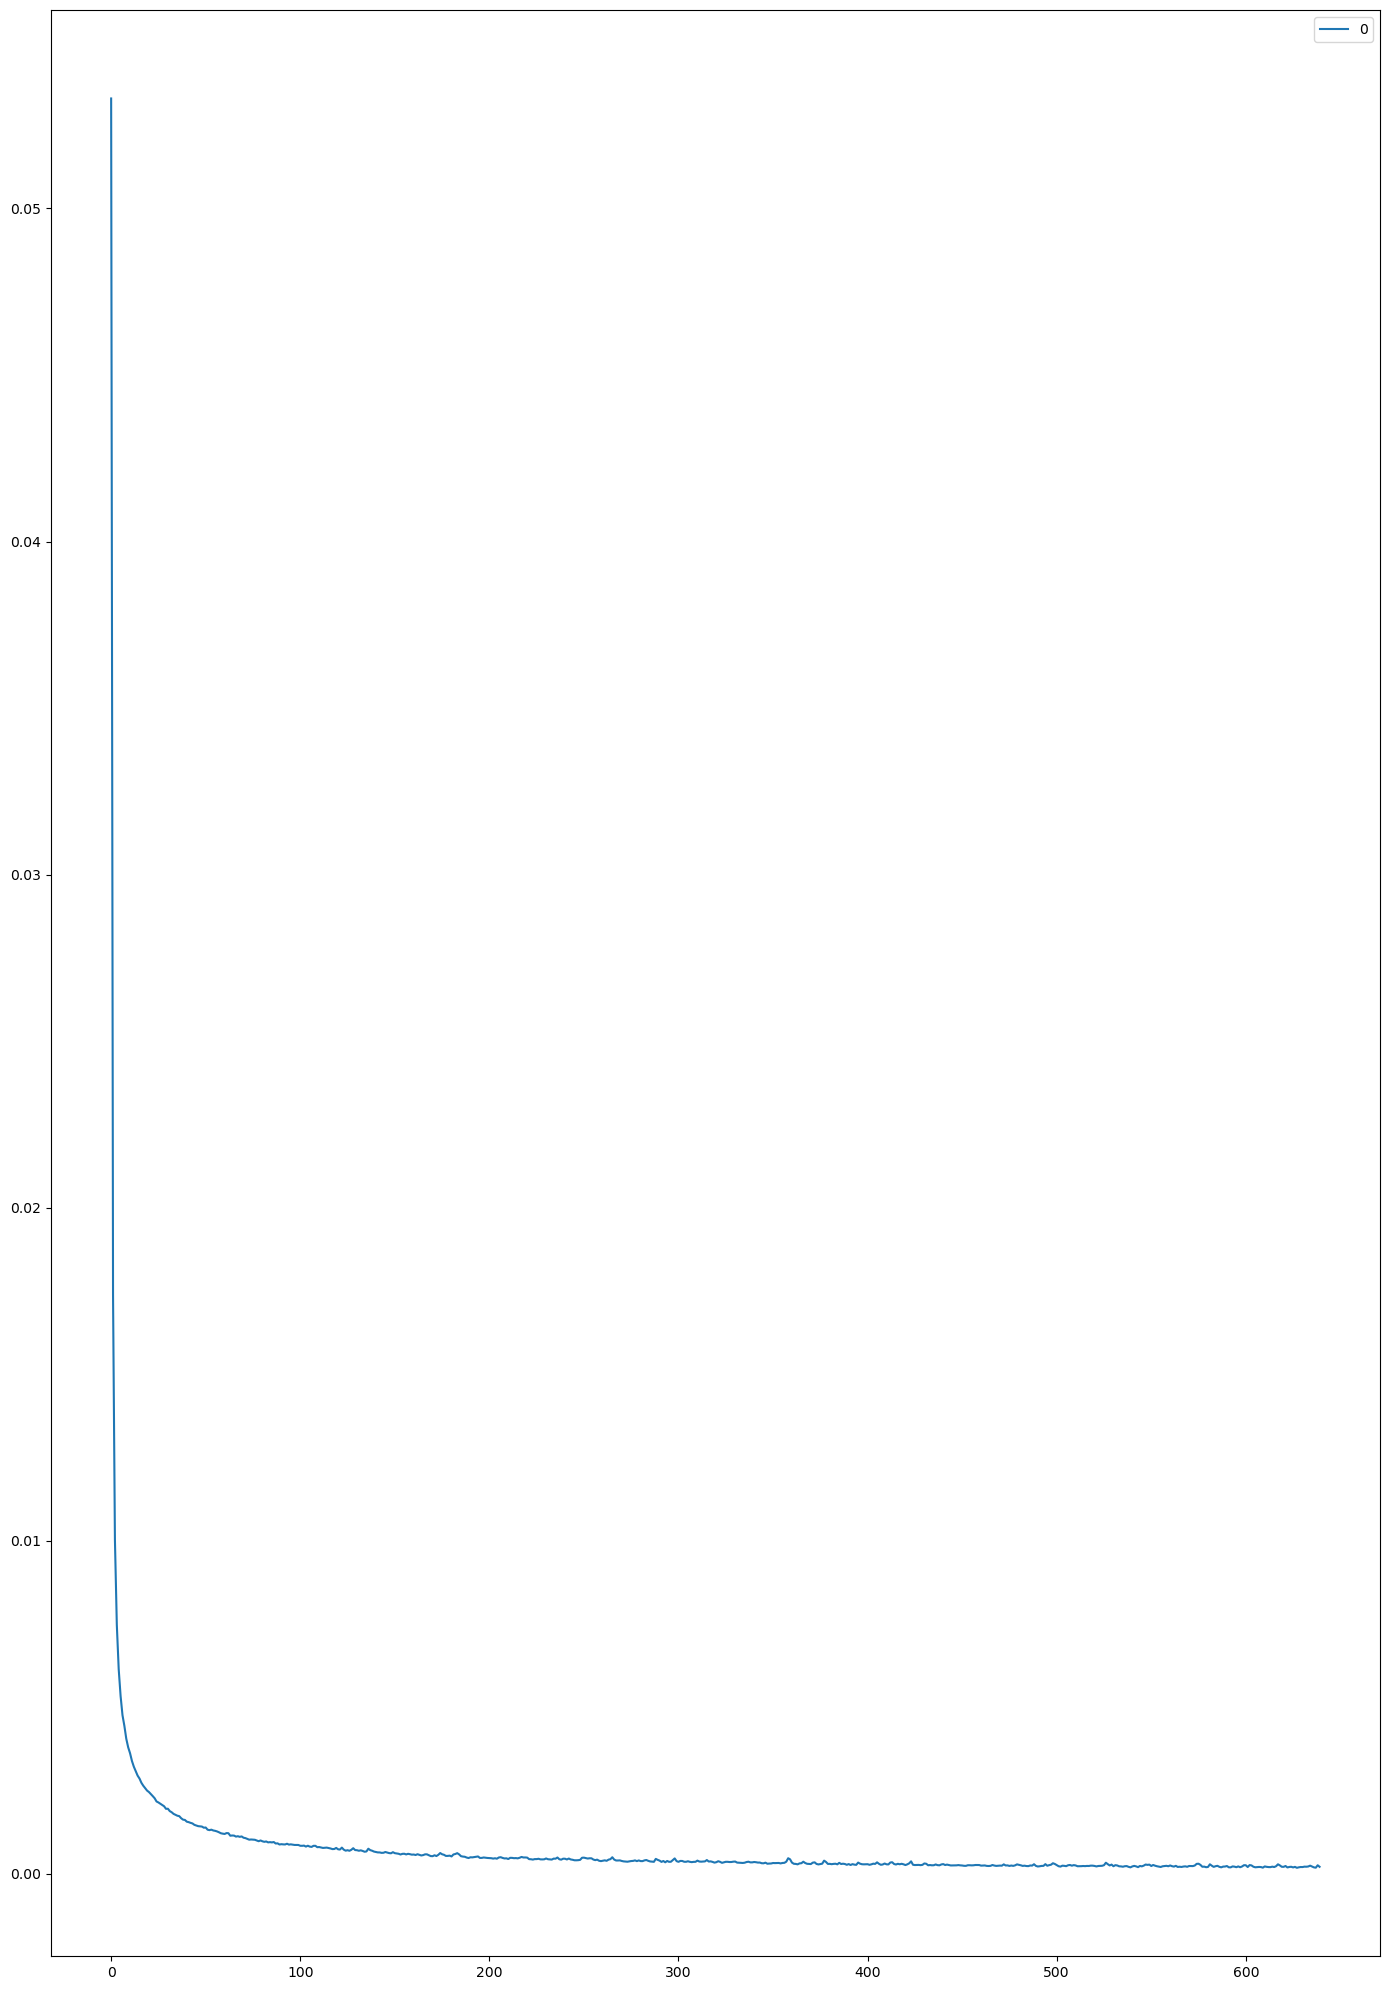

In [38]:
#Plotting the loss curve
pd.DataFrame(best_model_MLP.loss_curve_).plot()

In [39]:
#Calculating predictions for the training and testing set
y_train_pred_MLP = best_model_MLP.predict(X_train)
y_test_pred_MLP = best_model_MLP.predict(X_test)

In [40]:
#Calculating performance evaluation metrics
print(f"R2 Train: {r2_score(y_train, y_train_pred_MLP):.5f}")
print(f"R2 Test: {r2_score(y_test, y_test_pred_MLP):.5f}")
print(f"RMSE Train: {root_mean_squared_error(y_train, y_train_pred_MLP):.5f}")
print(f"RMSE Test: {root_mean_squared_error(y_test, y_test_pred_MLP):.5f}")
print(f"MAE Train: {mean_absolute_error(y_train, y_train_pred_MLP):.5f}")
print(f"MAE Test: {mean_absolute_error(y_test, y_test_pred_MLP):.5f}")

R2 Train: 0.99156
R2 Test: 0.98895
RMSE Train: 0.01709
RMSE Test: 0.01991
MAE Train: 0.00981
MAE Test: 0.01066


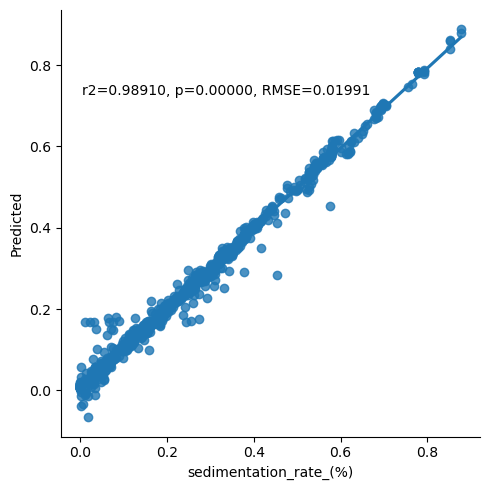

In [41]:
#Visualization Multi-Layer Perceptron
df = pd.DataFrame()
df['sedimentation_rate_(%)'] = y_test
df['Predicted'] = y_test_pred_MLP

g = sns.lmplot(x = 'sedimentation_rate_(%)', y = 'Predicted', data = df, ci = 90)
g.map_dataframe(annotate)
plt.show()

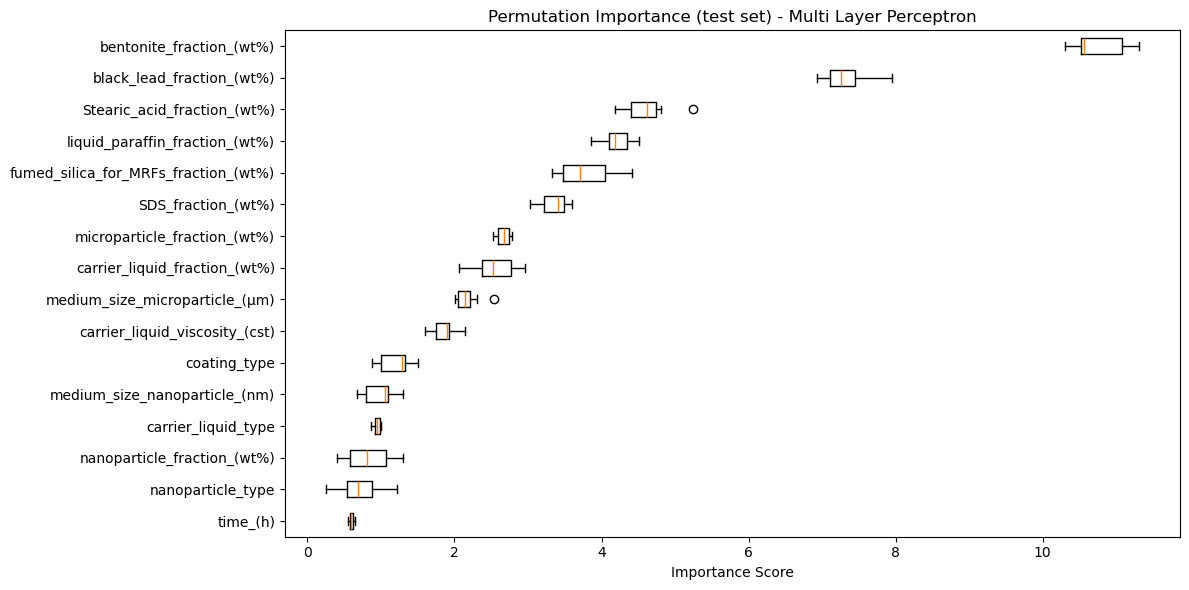

In [42]:
#Permutation in a Multi-Layer Perceptron model
#Calculation of the importance of variables by permutation
result = permutation_importance(
    best_model_MLP, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2
)

#Ordering the importance indices
sorted_idx_perm = result.importances_mean.argsort()

#Configuring the chart to display importance by permutation
fig, ax = plt.subplots(figsize=(12, 6))
ax.boxplot(
    result.importances[sorted_idx_perm].T,
    vert=False,
    labels=np.array(X.columns)[sorted_idx_perm]
)
ax.set_title("Permutation Importance (test set) - Multi Layer Perceptron")
ax.set_xlabel("Importance Score")

fig.tight_layout()
plt.show()

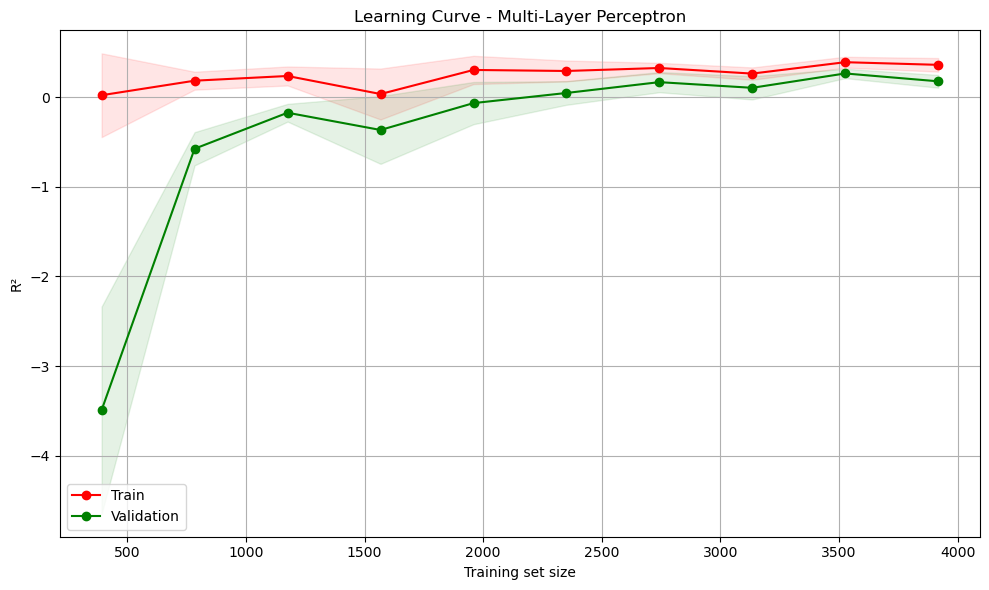

In [43]:
#Cross-validation
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

#Learning curves
train_sizes, train_scores, test_scores = learning_curve(
    estimator=best_model_MLP,
    X=X,
    y=y,
    cv=cv,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

#Means and deviations
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

#Plot
plt.figure(figsize=(10, 6))
plt.title("Learning Curve - Multi-Layer Perceptron")
plt.xlabel("Training set size")
plt.ylabel("R²")
plt.grid()

plt.fill_between(train_sizes,
                 train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std,
                 alpha=0.1, color="r")
plt.fill_between(train_sizes,
                 test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std,
                 alpha=0.1, color="g")

plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Train")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Validation")

plt.legend(loc="best")
plt.tight_layout()
plt.show()

In [44]:
#Grid Search Decision Tree (DT)
param_grid = {
    'max_depth': [8, 10, 12, 14, 16, 18],
    'min_samples_split': [3, 5, 10, 20, 30, 50],
    'min_samples_leaf': [ 2, 5, 10, 15],
    'max_features': ['sqrt', None]
}

regressor_DT = DecisionTreeRegressor(random_state=42)

grid_search_DT = GridSearchCV(
    regressor_DT,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search_DT.fit(X_train, y_train)

print("Best parameters found::", grid_search_DT.best_params_)
print("Best R² (cross validation):", grid_search_DT.best_score_)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Best parameters found:: {'max_depth': 18, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 3}
Best R² (cross validation): 0.9834638122121463


In [45]:
#Decision Tree (DT) Regressor model
best_model_DT = grid_search_DT.best_estimator_

In [46]:
#Calculating predictions for the training and testing set
y_train_pred_DT = best_model_DT.predict(X_train)
y_test_pred_DT = best_model_DT.predict(X_test)

In [47]:
#Calculating performance evaluation metrics
print(f"R2 Train: {r2_score(y_train, y_train_pred_DT):.5f}")
print(f"R2 Test: {r2_score(y_test, y_test_pred_DT):.5f}")
print(f"RMSE Train: {root_mean_squared_error(y_train, y_train_pred_DT):.5f}")
print(f"RMSE Test: {root_mean_squared_error(y_test, y_test_pred_DT):.5f}")
print(f"MAE Train: {mean_absolute_error(y_train, y_train_pred_DT):.5f}")
print(f"MAE Test: {mean_absolute_error(y_test, y_test_pred_DT):.5f}")

R2 Train: 0.99772
R2 Test: 0.98971
RMSE Train: 0.00889
RMSE Test: 0.01922
MAE Train: 0.00335
MAE Test: 0.00720


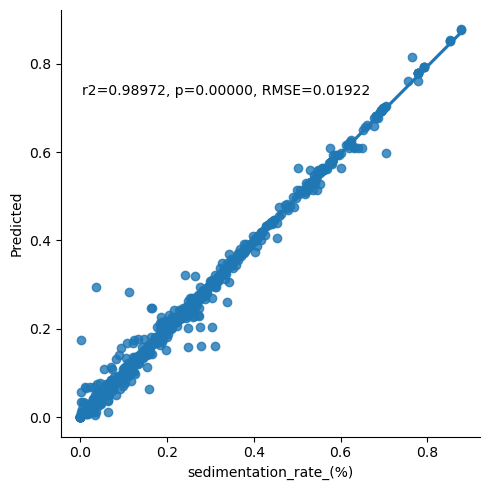

In [48]:
#Visualization Decision Tree
df = pd.DataFrame()
df['sedimentation_rate_(%)'] = y_test
df['Predicted'] = y_test_pred_DT

g = sns.lmplot(x = 'sedimentation_rate_(%)', y = 'Predicted', data = df, ci = 90)
g.map_dataframe(annotate)
plt.show()

[6.57406363e-03 1.14689162e-01 1.28836693e-01 3.48426619e-02
 3.32202922e-01 2.56660246e-03 1.49652993e-05 7.28082760e-04
 0.00000000e+00 7.13536493e-02 2.48490427e-02 1.25118717e-01
 0.00000000e+00 9.57634756e-03 2.21688603e-05 1.48624922e-01]


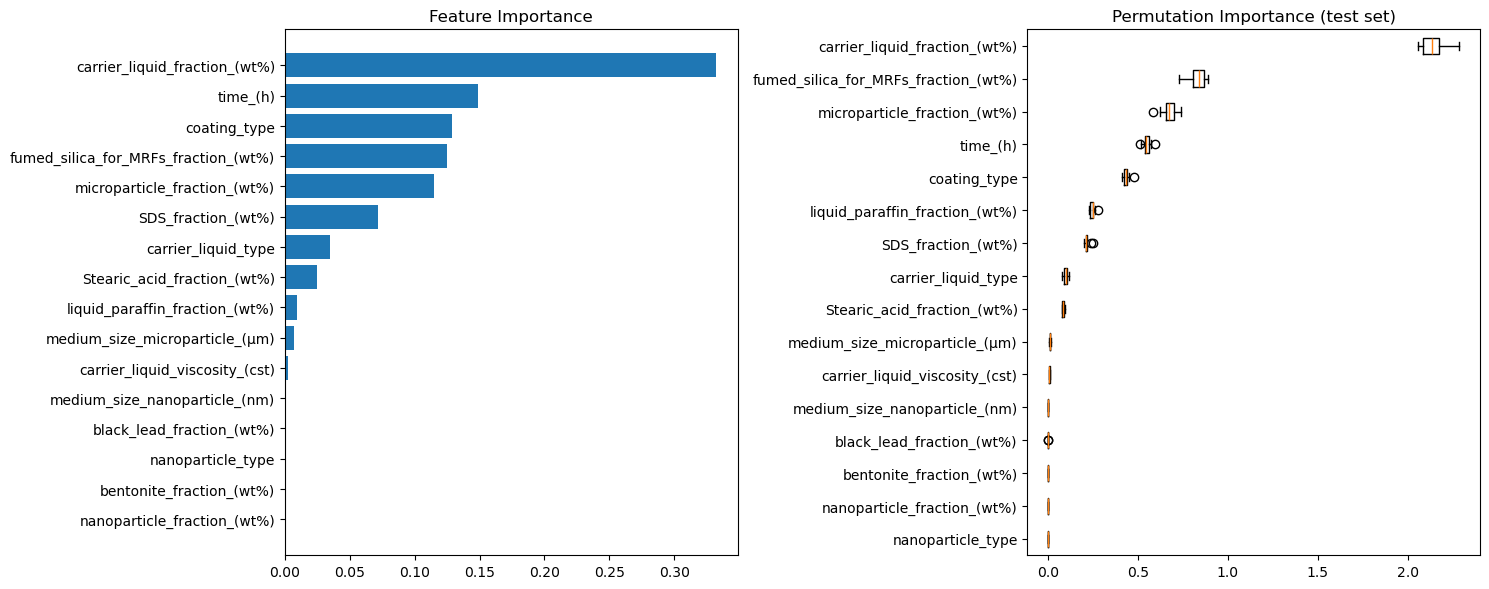

In [49]:
#Feature importance in a Decision Tree model
feature_importance = best_model_DT.feature_importances_
sorted_idx = np.argsort(feature_importance)
print(feature_importance)
pos = np.arange(sorted_idx.shape[0]) + 0.5
fig = plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.barh(pos, feature_importance[sorted_idx], align="center")
plt.yticks(pos, np.array(X.columns.values.tolist())[sorted_idx])
plt.title("Feature Importance")

result = permutation_importance(
    best_model_DT, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2
)
sorted_idx = result.importances_mean.argsort()
plt.subplot(1, 2, 2)
plt.boxplot(
    result.importances[sorted_idx].T,
    vert=False,
    labels=np.array(X.columns.values.tolist())[sorted_idx],
)
plt.title("Permutation Importance (test set)")
fig.tight_layout()
plt.show()

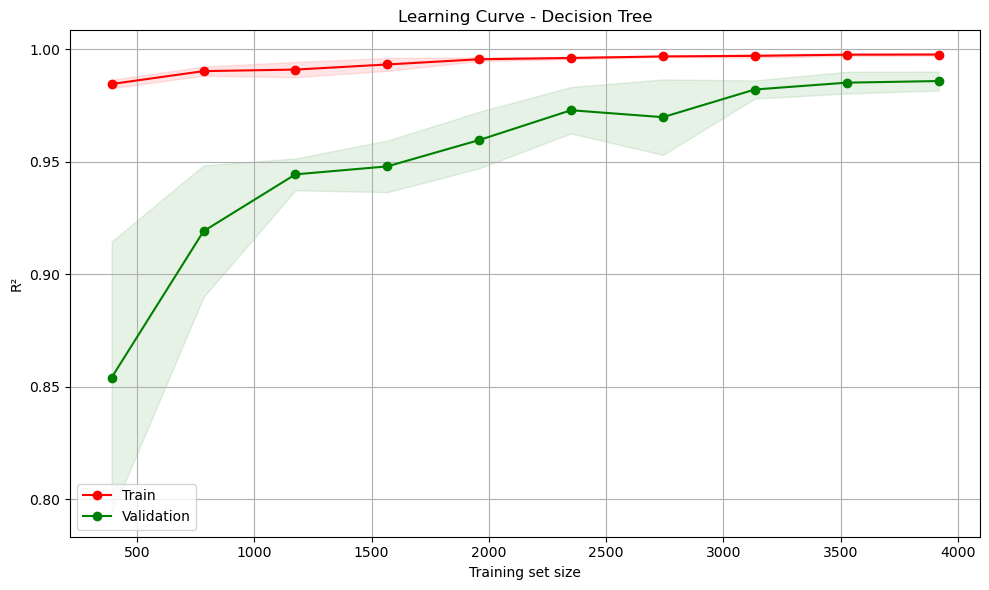

In [50]:
#Cross-validation
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

#Learning cruves
train_sizes, train_scores, test_scores = learning_curve(
    estimator=best_model_DT,
    X=X,
    y=y,
    cv=cv,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

#Means and deviations
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

#Plot
plt.figure(figsize=(10, 6))
plt.title("Learning Curve - Decision Tree")
plt.xlabel("Training set size")
plt.ylabel("R²")
plt.grid()

plt.fill_between(train_sizes,
                 train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std,
                 alpha=0.1, color="r")
plt.fill_between(train_sizes,
                 test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std,
                 alpha=0.1, color="g")

plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Train")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Validation")

plt.legend(loc="best")
plt.tight_layout()
plt.show()

In [51]:
#Grid Search Gradient Boosting (GB)
param_grid_GB = {
    'n_estimators': [300, 500, 800],               
    'learning_rate': [0.1, 0.05, 0.02, 0.01],            
    'max_depth': [3, 4, 5, 6],                        
    'subsample': [0.8, 1.0],                       
}


regressor_GB_base = GradientBoostingRegressor(
    random_state=42,
    min_samples_split=20,                          
    min_samples_leaf=5,                            
    n_iter_no_change=10,                           
    validation_fraction=0.1                
)


grid_search_GB = GridSearchCV(
    estimator=regressor_GB_base,
    param_grid=param_grid_GB,
    cv=5,
    scoring='r2',
    verbose=1,
    n_jobs=-1
)


grid_search_GB.fit(X_train, y_train)


print("Best parameters found:", grid_search_GB.best_params_)
print("Best R² (cross validation):", grid_search_GB.best_score_)

Fitting 5 folds for each of 96 candidates, totalling 480 fits
Best parameters found: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.8}
Best R² (cross validation): 0.988685602271979


In [52]:
#Gradient Boosting (GB) Regressor model
best_model_GB = grid_search_GB.best_estimator_

In [53]:
#Calculating predictions for the training and testing set
y_train_pred_GB = best_model_GB.predict(X_train)
y_test_pred_GB = best_model_GB.predict(X_test)

In [54]:
#Calculating performance evaluation metrics
print(f"R2 Train: {r2_score(y_train, y_train_pred_GB):.5f}")
print(f"R2 Test: {r2_score(y_test, y_test_pred_GB):.5f}")
print(f"RMSE Train: {root_mean_squared_error(y_train, y_train_pred_GB):.5f}")
print(f"RMSE Test: {root_mean_squared_error(y_test, y_test_pred_GB):.5f}")
print(f"MAE Train: {mean_absolute_error(y_train, y_train_pred_GB):.5f}")
print(f"MAE Test: {mean_absolute_error(y_test, y_test_pred_GB):.5f}")

R2 Train: 0.99351
R2 Test: 0.99055
RMSE Train: 0.01499
RMSE Test: 0.01842
MAE Train: 0.01104
MAE Test: 0.01317


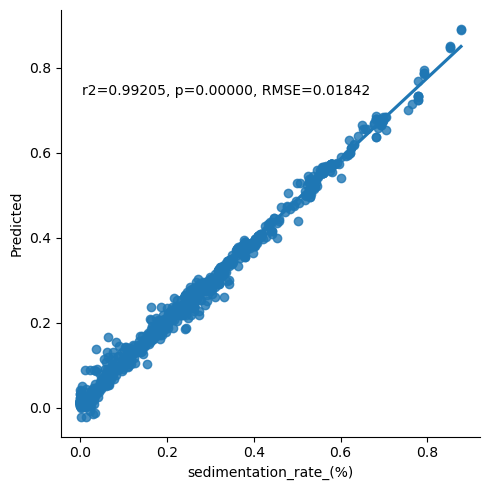

In [55]:
#Visualization Gradient Boosting
df = pd.DataFrame()
df['sedimentation_rate_(%)'] = y_test
df['Predicted'] = y_test_pred_GB

g = sns.lmplot(x = 'sedimentation_rate_(%)', y = 'Predicted', data = df, ci = 90)
g.map_dataframe(annotate)
plt.show()

[4.33106841e-02 5.27052587e-02 1.28565342e-01 9.97963703e-03
 3.02422388e-01 2.16845894e-02 8.82252616e-03 5.51944844e-04
 2.23910637e-04 6.85831180e-02 4.53266596e-02 1.48804368e-01
 2.55276846e-03 5.77452795e-04 4.36372543e-04 1.65452979e-01]


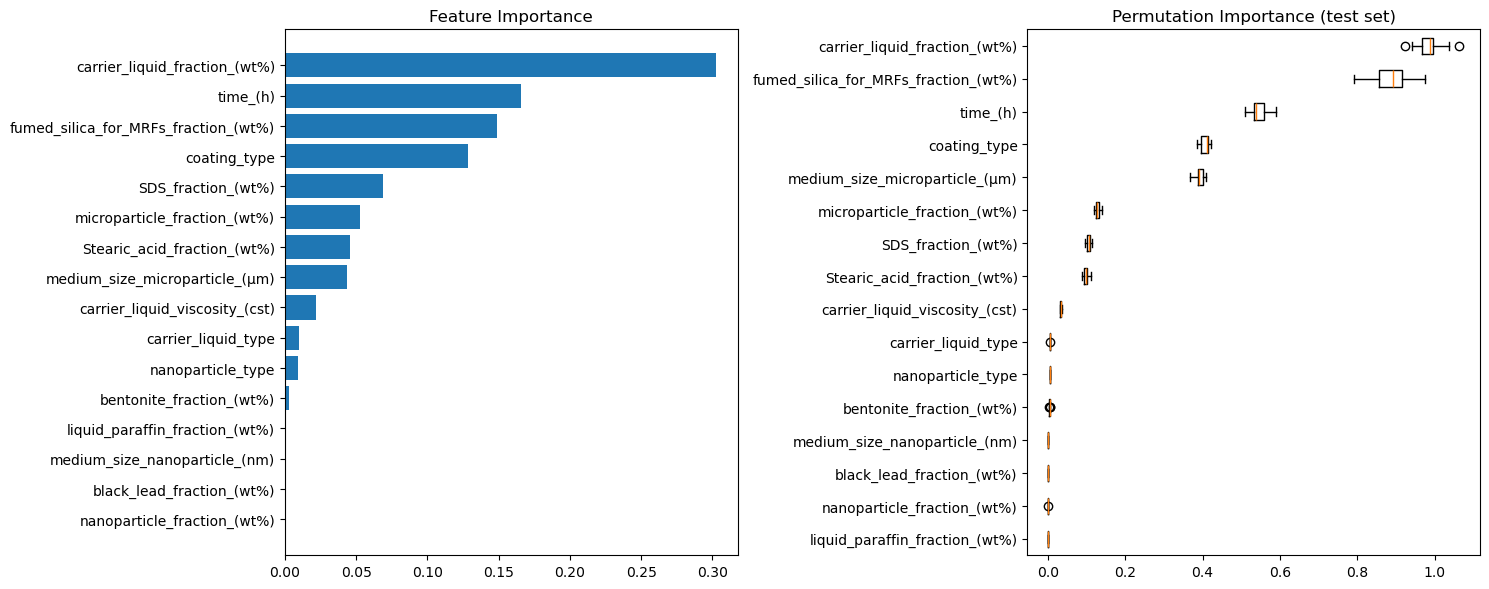

In [56]:
#Feature importance in a Gradient Boosting model
feature_importance = best_model_GB.feature_importances_
sorted_idx = np.argsort(feature_importance)
print(feature_importance)
pos = np.arange(sorted_idx.shape[0]) + 0.5
fig = plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.barh(pos, feature_importance[sorted_idx], align="center")
plt.yticks(pos, np.array(X.columns.values.tolist())[sorted_idx])
plt.title("Feature Importance")

result = permutation_importance(
    best_model_GB, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2
)
sorted_idx = result.importances_mean.argsort()
plt.subplot(1, 2, 2)
plt.boxplot(
    result.importances[sorted_idx].T,
    vert=False,
    labels=np.array(X.columns.values.tolist())[sorted_idx],
)
plt.title("Permutation Importance (test set)")
fig.tight_layout()
plt.show()

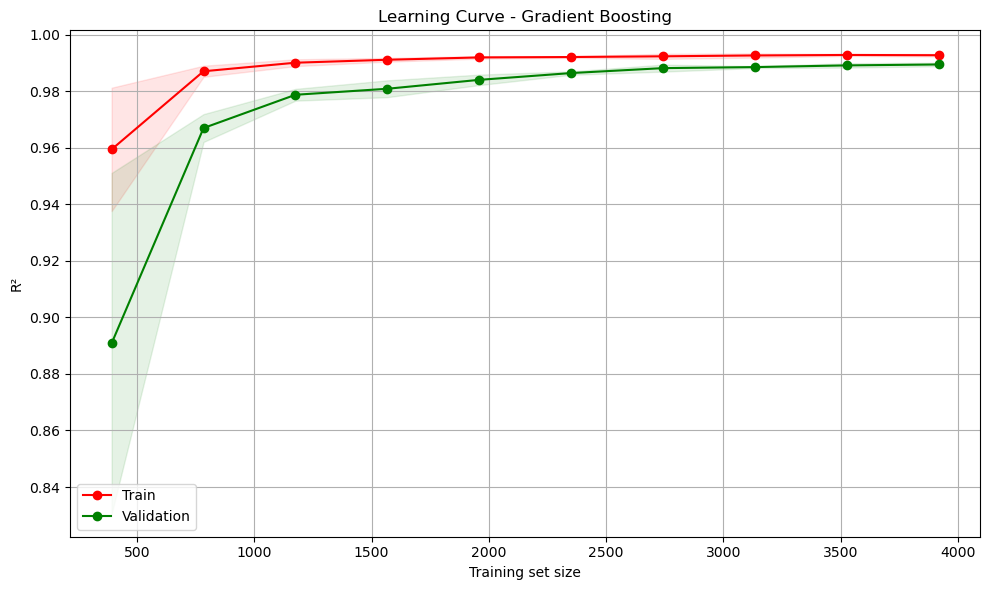

In [57]:
#Cross-validation
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

#Learning curves
train_sizes, train_scores, test_scores = learning_curve(
    estimator=best_model_GB,
    X=X,
    y=y,
    cv=cv,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

#Means and deviations
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

#Plot
plt.figure(figsize=(10, 6))
plt.title("Learning Curve - Gradient Boosting")
plt.xlabel("Training set size")
plt.ylabel("R²")
plt.grid()

plt.fill_between(train_sizes,
                 train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std,
                 alpha=0.1, color="r")
plt.fill_between(train_sizes,
                 test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std,
                 alpha=0.1, color="g")

plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Train")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Validation")

plt.legend(loc="best")
plt.tight_layout()
plt.show()

In [58]:
#Grid Search Random Forest (RF)
param_grid = {
    'n_estimators': [500, 1000],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

grid_search_RF = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search_RF.fit(X_train, y_train)

print("Best parameters found:", grid_search_RF.best_params_)
print("Best R² (cross validation):", grid_search_RF.best_score_)


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters found: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}
Best R² (cross validation): 0.9942959758536125


In [59]:
#Random Forest (RF) Regressor model
best_model_RF = grid_search_RF.best_estimator_

In [60]:
#Calculating predictions for the training and testing set
y_train_pred_RF = best_model_RF.predict(X_train)
y_test_pred_RF = best_model_RF.predict(X_test)

In [61]:
#Calculating performance evaluation metrics
print(f"R2 Train: {r2_score(y_train, y_train_pred_RF):.5f}")
print(f"R2 Test: {r2_score(y_test, y_test_pred_RF):.5f}")
print(f"RMSE Train: {root_mean_squared_error(y_train, y_train_pred_RF):.5f}")
print(f"RMSE Test: {root_mean_squared_error(y_test, y_test_pred_RF):.5f}")
print(f"MAE Train: {mean_absolute_error(y_train, y_train_pred_RF):.5f}")
print(f"MAE Test: {mean_absolute_error(y_test, y_test_pred_RF):.5f}")

R2 Train: 0.99924
R2 Test: 0.99629
RMSE Train: 0.00513
RMSE Test: 0.01154
MAE Train: 0.00214
MAE Test: 0.00522


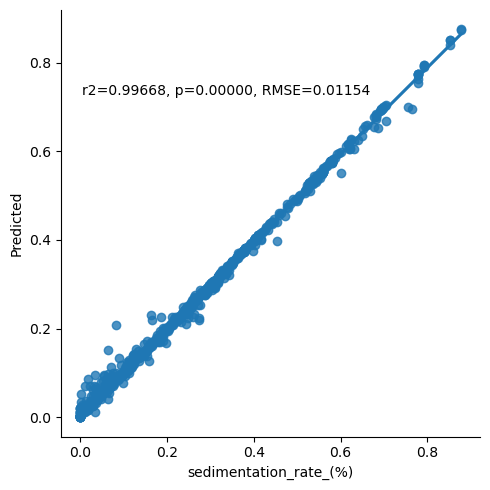

In [62]:
#Visualization Random Forest
df = pd.DataFrame()
df['sedimentation_rate_(%)'] = y_test
df['Predicted'] = y_test_pred_RF

g = sns.lmplot(x = 'sedimentation_rate_(%)', y = 'Predicted', data = df, ci = 90)
g.map_dataframe(annotate)
plt.show()

[0.04071283 0.11671837 0.13237344 0.00640726 0.18219302 0.01337316
 0.01050139 0.0064084  0.00698597 0.04331437 0.06019397 0.14191735
 0.0135817  0.01247634 0.0103993  0.20244315]


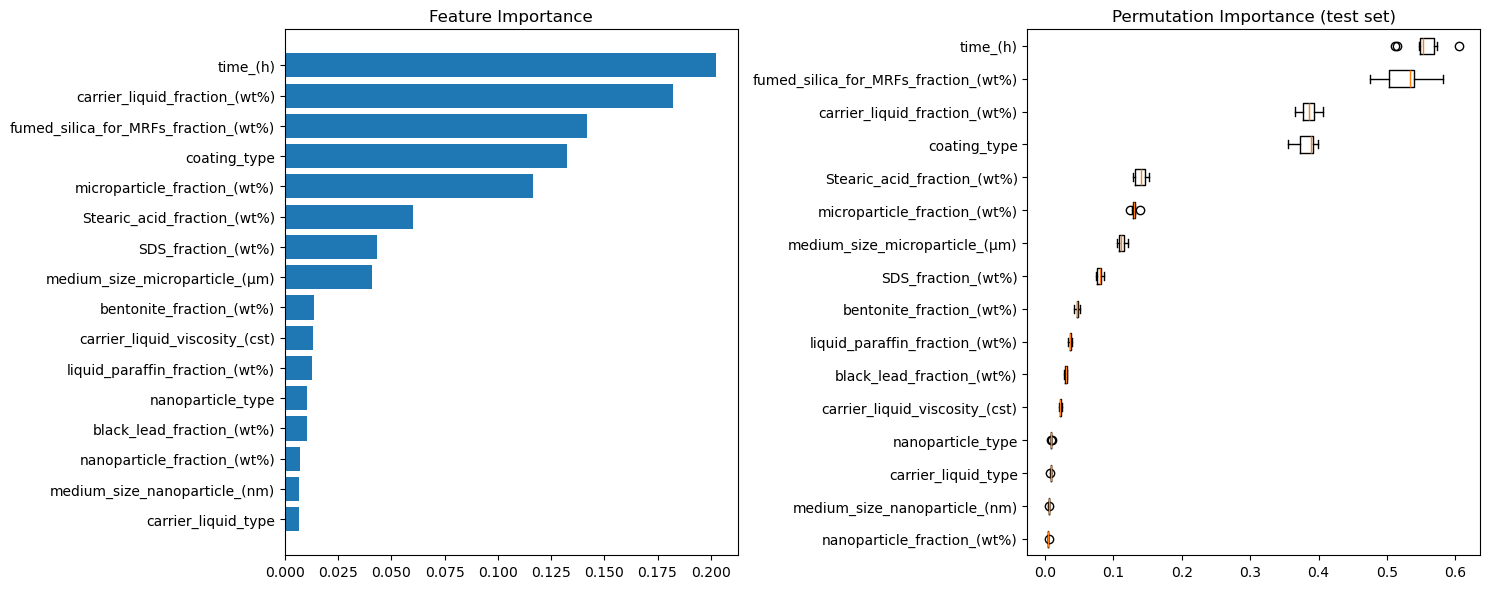

In [63]:
#Feature importance in a Random Forest model
feature_importance = best_model_RF.feature_importances_
sorted_idx = np.argsort(feature_importance)
print(feature_importance)
pos = np.arange(sorted_idx.shape[0]) + 0.5
fig = plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.barh(pos, feature_importance[sorted_idx], align="center")
plt.yticks(pos, np.array(X.columns.values.tolist())[sorted_idx])
plt.title("Feature Importance")

result = permutation_importance(
    best_model_RF, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2
)
sorted_idx = result.importances_mean.argsort()
plt.subplot(1, 2, 2)
plt.boxplot(
    result.importances[sorted_idx].T,
    vert=False,
    labels=np.array(X.columns.values.tolist())[sorted_idx],
)
plt.title("Permutation Importance (test set)")
fig.tight_layout()
plt.show()

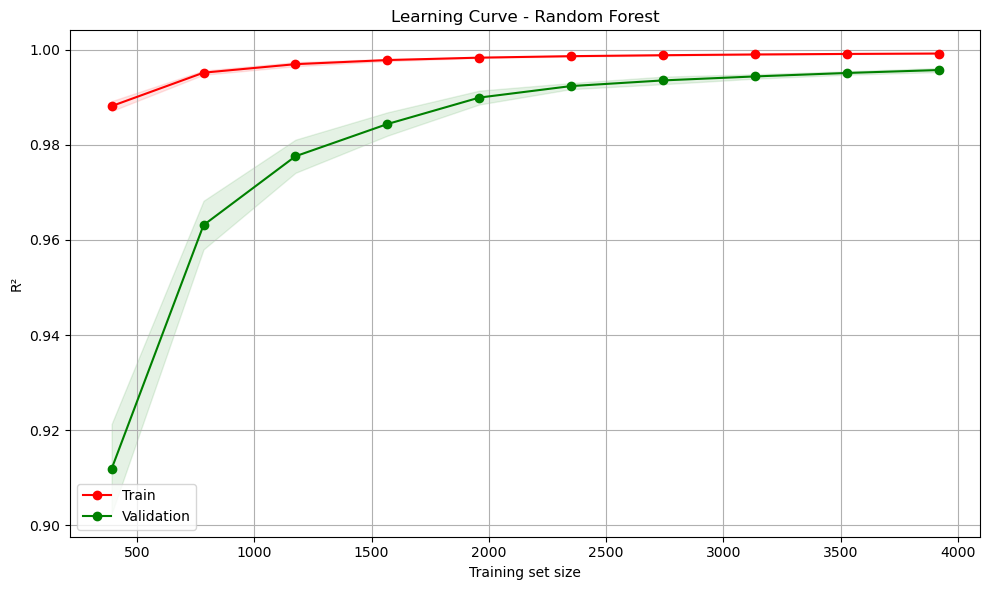

In [64]:
#Cross-validation
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

#Learning curves
train_sizes, train_scores, test_scores = learning_curve(
    estimator=best_model_RF,
    X=X,
    y=y,
    cv=cv,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

#Means and deviations
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

#Plot
plt.figure(figsize=(10, 6))
plt.title("Learning Curve - Random Forest")
plt.xlabel("Training set size")
plt.ylabel("R²")
plt.grid()

plt.fill_between(train_sizes,
                 train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std,
                 alpha=0.1, color="r")
plt.fill_between(train_sizes,
                 test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std,
                 alpha=0.1, color="g")

plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Train")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Validation")

plt.legend(loc="best")
plt.tight_layout()
plt.show()